# Fetal Circulation Model  
## Gestational Scaling

This notebook compares:

1. A **baseline simulation** (no gestational scaling)
2. A **Pennati-scaled simulation** (R, C, L scaled with gestational age)

We extract and compare:
- Blood flows: MPA, AAo, SVC, DAo, DA, PBF, FO, CVO
- Pulsatility Index (PI): UmA, MCA
- Traces




## 1. Imports and model loading


In [78]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import libcellmlSolver.libcellMLWrapper as W
import libcellmlSolver.model as M
import sys,numpy as np
from setuptools import Extension, setup
from Cython.Build import cythonize
import importlib, matplotlib.pyplot as plt, pandas
import os
import libcellmlSolver
import functions_to_import as fhealthy

import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [79]:
import ctypes
ctypes.CDLL('/usr/local/lib/libsundials_core.so.7', mode = ctypes.RTLD_GLOBAL)
ctypes.CDLL('/usr/local/lib/libsundials_cvode.so.7', mode = ctypes.RTLD_GLOBAL)
ctypes.CDLL('/usr/local/lib/libsundials_kinsol.so.7', mode = ctypes.RTLD_GLOBAL)

<CDLL '/usr/local/lib/libsundials_kinsol.so.7', handle 320f00f0 at 0x78be8d781eb0>

In [80]:
PATH_MODEL = "/home/mirei/TFM/opencorProcess/models/model_fetal_36/model_fetal_36/Main.cellml"
SUNDIALS_INCLUDE = "/home/mirei/TFM/sundialsinst/include"
SUNDIALS_LIB = "/usr/local/lib"


def load_model():
    wrapper = W.LibcellMLWrapper.createFromCellML(
        PATH_MODEL,
        sundials_include_path=SUNDIALS_INCLUDE,
        sundials_lib_path=SUNDIALS_LIB
    )
    return M.ModelSolver(wrapper=wrapper)


## 2. Scaling


### 2.1. Fetal weigth model

Pennati et al. (2000):
$$\log_{10}(W) = 0.2508 + 0.1458 \cdot GA - 0.0016 \cdot GA^2$$


Defines fetal mass as a function of gestational age.

In [81]:
import scipy

# Fetal weight estimation
def fetal_weight(GA):
    """
    GA in weeks
    Returns fetal weight in grams
    """
    return 10**(0.2508 + 0.1458*GA - 0.0016*GA**2)

# Percentile weight estimation
def percentile_weight(GA, percentile):

    FW50 = fetal_weight(GA)
    sigma = 0.12
    z = scipy.stats.norm.ppf(percentile)

    FW = FW50 * np.exp(z * sigma)

    return FW

In [82]:
# print weigth percentiles at 20, 30 and 40 weeks
for GA in [20, 30, 40]:
    print(f"GA: {GA} weeks")
    for percentile in [0.1, 0.5, 0.9]:
        FW = percentile_weight(GA, percentile)
        print(f"  Percentile: {percentile*100:.1f}%, Fetal weight: {FW:.2f} g")
        
# print normal fetal weigth at 20, 30 and 40 weeks
for GA in [20, 30, 40]:
    FW = fetal_weight(GA)
    print(f"GA: {GA} weeks, Fetal weight: {FW:.2f} g")
    

GA: 20 weeks
  Percentile: 10.0%, Fetal weight: 288.41 g
  Percentile: 50.0%, Fetal weight: 336.36 g
  Percentile: 90.0%, Fetal weight: 392.27 g
GA: 30 weeks
  Percentile: 10.0%, Fetal weight: 1312.23 g
  Percentile: 50.0%, Fetal weight: 1530.38 g
  Percentile: 90.0%, Fetal weight: 1784.80 g
GA: 40 weeks
  Percentile: 10.0%, Fetal weight: 2857.67 g
  Percentile: 50.0%, Fetal weight: 3332.73 g
  Percentile: 90.0%, Fetal weight: 3886.77 g
GA: 20 weeks, Fetal weight: 336.36 g
GA: 30 weeks, Fetal weight: 1530.38 g
GA: 40 weeks, Fetal weight: 3332.73 g


Kiserud et al.(2017):

In [83]:
def fetal_weight_2(GA): 
    return (-3.07*(GA/40)**3 + 14.06*(GA/40)**2 - 9.04*(GA/40) + 1.7)*1000

### 2.2. Placenta weigth model

Baller et al. (2019):
Placenta is scaled with metabolic Kleiber law: $$P_w(t) = \alpha (t) \cdot F_w(t)^{3/4}$$

With: $$ \alpha(t) = 247.97 \cdot t^{-0.97}$$ with time in days

In [84]:
def placenta_weight(GA_weeks, FW):
    """
    Computes placenta weight in grams based on gestational age and fetal weight.
    Equation: P_W = alpha(t) * FW^(3/4)
    """
    t_days = GA_weeks * 7.0
    
    beta = 0.75 
    alpha = 247.97 * (t_days ** -0.97)
    
    PW_g = alpha * (FW ** beta) # Placenta weight in grams
    
    return PW_g 

### 2.3. Fetal heart rate model 

Yigit et al., (2015):  https://doi.org/10.1016/j.jbiomech.2015.02.040

$$ f_{HR} (GA) = -20 * (GA/40) + 160 $$


In [85]:
def fetal_heart_rate(GA):
    return -20*(GA/40) + 160

def tc(fetal_heart_rate):
    return 60 / fetal_heart_rate

## 3. Generic scaling law

All parameters are scaled as:

$$Y = Y0 * (W/W0)^b$$

Except placenta that is scaled with placenta weigth


In [86]:
# --- Scaling functions ---

from matplotlib.pylab import percentile


# --- Scaling functions for fetal weight ---

def scale_parameter(m, comp, var, b, GA, GA_ref=36):
    FW = fetal_weight(GA)/1000
    FW0 = fetal_weight(GA_ref)/1000

    Y0 = m.getConstant(comp, var)
    Y = Y0 * (FW / FW0) ** b

    m.setConstantOrState0(comp, var, Y)


# --- Scaling functions for fetal weight percentiles ---

def scale_parameter_weight_percentile(m, comp, var, b, GA, percentile=0.5, GA_ref=36):

    FW  = percentile_weight(GA, percentile) / 1000
    FW0 = fetal_weight(GA_ref) / 1000
    
    Y0 = m.getConstant(comp, var)
    Y = Y0 * (FW / FW0)**b

    m.setConstantOrState0(comp, var, Y)


# --- Scaling functions mixed case ---

def scale_parameter_mixed(m, comp, var, b_ga, b_w, GA, percentile=0.5, GA_ref=36):

    Y0 = m.getConstant(comp, var)
    FW50 = fetal_weight(GA)
    FW = percentile_weight(GA, percentile)

    # maturation term
    ga_term = (GA / GA_ref)**b_ga

    # size term
    size_term = (FW / FW50)**b_w

    Y = Y0 * ga_term * size_term

    m.setConstantOrState0(comp, var, Y)


# --- Scaling functions for fetal GA ---

def scale_parameter_ga(m, comp, var, b, GA, GA_ref=36):
    Y0 = m.getConstant(comp, var)
    Y = Y0 * (GA / GA_ref) ** b

    m.setConstantOrState0(comp, var, Y)


# --- Scaling functions for placenta parameters ---
    
def scale_parameter_placenta(m, comp, var, b, GA, GA_ref=36):
    PW = placenta_weight(GA, fetal_weight(GA))/1000
    PW0 = placenta_weight(GA_ref, fetal_weight(GA_ref))/1000

    Y0 = m.getConstant(comp, var)
    Y = Y0 * (PW / PW0) ** b

    m.setConstantOrState0(comp, var, Y)


def is_foo(var):
    return "foo" in var.lower()


def scaling_param_weight(weight,ref_param, b):
    parameter = ref_param*(weight/2666.86)**b # 2720 is the fetal weight at 36 weeks in grams
    return parameter

In [87]:
# scaling function comparation between scale_parameter and scale_parameter_weight_percentile for GA = 20 weeks and percentiles 10%, 50% and 90%
GA = 20
for percentile in [0.1, 0.5, 0.9]:
    print(f"GA: {GA} weeks, Percentile: {percentile*100:.1f}%")
    FW_percentile = percentile_weight(GA, percentile)
    FW_normal = fetal_weight(GA)
    print(f"  Fetal weight: {FW_percentile:.2f} g, Normal fetal weight: {FW_normal:.2f} g")
    scaled_param_percentile = scaling_param_weight(FW_percentile, ref_param=1.0, b=-1.0) # example with ref_param=1.0 and b=-1.0
    scaled_param_normal = scaling_param_weight(FW_normal, ref_param=1.0, b=-1.0)
    print(f"  Scaled parameter (percentile): {scaled_param_percentile:.4f}, Scaled parameter (normal): {scaled_param_normal:.4f}")


GA: 20 weeks, Percentile: 10.0%
  Fetal weight: 288.41 g, Normal fetal weight: 336.36 g
  Scaled parameter (percentile): 9.2467, Scaled parameter (normal): 7.9287
GA: 20 weeks, Percentile: 50.0%
  Fetal weight: 336.36 g, Normal fetal weight: 336.36 g
  Scaled parameter (percentile): 7.9287, Scaled parameter (normal): 7.9287
GA: 20 weeks, Percentile: 90.0%
  Fetal weight: 392.27 g, Normal fetal weight: 336.36 g
  Scaled parameter (percentile): 6.7985, Scaled parameter (normal): 7.9287


## 4. Parameter groups for GA scaling 

According to Pennati (2000):
- Brain and lungs scale differently
- DV, DA, and FO have specific rules
- Parameters containing `foo` must never be scaled


In [88]:
# Brain
BRAIN_R = {"R_R_br", "R_L_br", "R_R_br_p", "R_L_br_p"}
BRAIN_C = {"C_R_br", "C_L_br"}

# Lungs
LUNG_R = {"Rlung"}
LUNG_C = {"Clung"}

# Ductus venosus
DV_R = {"Rdv_ra", "Rdv_fo"}
DV_L = {"Ldv"}

# Ductus arteriosus
DA_R = {"Rda"}
DA_L = {"Lda"}

# Foramen ovale (only D is scaled)
FO_D = {"Dfo"}

# Placenta
PLAC_R = {"Rplac", "Rplac_prox"}
PLAC_C = {"Cplac", "Cplacprox"}

# Resistance of the rest of the body
R_SCALE = {
"Rla","Rsvc","Ruv","Rivc","Rbct",
"R_R_SC","R_L_SC","R_R_ICA","R_L_ICA","Risthm","Rdtao",
"Rrev","Rporv","Rfv","Rua","Rhv",
"R_R_ub","R_L_ub","R_R_CCA","R_L_CCA", "Rdaao",
"R_R_ub_p","R_L_ub_p","Rfa",
"Rha","Rivc_ra","Rivc_la","Rmea","Relg","R0_Coronary",
"Rrea"
}

# Aorta
R_A_SCALE = {
"Raa", "RaAoA", "RdAoA"
}

C_A_SCALE = {
"Caa", "CaAoA", "CdAoA"
}

# Pulmonary artery
R_PA_SCALE = {
"Rpa"
}

C_PA_SCALE = {
"Cpa"
}

# Compliance of the rest of the body
C_SCALE = {
"Csvc","Cao2","Cuv","Civc",
"Cbct","C_R_SC","C_R_ICA","C_L_ICA","C_L_SC","Cisthm","Cao1",
"Ckid","Cinte","Cleg","Cua","Che",
"C_R_ub","C_R_CCA","C_L_CCA","C_L_ub"
}

# Inertia of the rest of the body
L_SCALE = {
"Laa","LaAoA","LdAoA","Lpa","Lbct","L_R_SC","L_R_ICA","L_L_ICA",
"L_L_SC","Listhm","L_L_CCA","L_R_CCO"
}

# Wall volumes
V_SCALE = {
"Vwall_la","Vwall_lv","Vwall_ra","Vwall_rv"
}

# Unstressed volumes
V0_SCALE = {
"Vla0","Vlv0","Vra0","Vrv0" # initial values of the state variables for the volumes
}

# Reference areas
A_SCALE_R = {
"Amref_ra","Amref_rv"
}
A_SCALE_L = {
"Amref_la","Amref_lv"
}

# Valves areas
A_VALVE_SCALE = {
"Ami", "Atr", "Aao", "Apv", "Adv", "Afo", "Amdead_ra", "Amdead_la", "Atrdead_rv", "Atrdead_lv"
}

# Stress
STRESS_SCALE = {
"spas_a", "sact_a", "spas_v"
}

STRESS_SCALE_V = {
"sact_v"
}

# B parameters
B_SCALE = {
"BdAoA", "Bisthm", "Bmpa", "Bda"
}

# Time
T_SCALE = {
"p_tact_a", "p_tact_v"
}

T_DECAY_SCALE = {
"p_td_a", "p_td_v"
}


## 5. Full scaling implementation


In [89]:
from matplotlib import scale


def apply_full_scaling(m, GA, percentile=0.5):

    for comp, var in m.getAllNames():

        if comp != "Parameters":
            continue

        if is_foo(var):
            continue

        # Brain
        if var in BRAIN_R:
            if 26 <=  GA < 28:
                scale_parameter_mixed(m, comp, var, b_ga=-3.53, b_w=-1.00, GA=GA, percentile=percentile); continue #-3.63
            elif 30 > GA >= 28:
                scale_parameter_mixed(m, comp, var, b_ga=-3.7, b_w=-1.00, GA=GA, percentile=percentile); continue #-3.8
            elif GA < 26:
                scale_parameter_mixed(m, comp, var, b_ga=-3.63, b_w=-1.00, GA=GA, percentile=percentile); continue #-3.73
            elif GA >= 30:
                scale_parameter_mixed(m, comp, var, b_ga=-3.2, b_w=-1.00, GA=GA, percentile=percentile); continue #-1.2
        if var in BRAIN_C:
            if 26 <=  GA < 28:
                scale_parameter_mixed(m, comp, var, b_ga=+4.45, b_w=+1.33, GA=GA, percentile=percentile); continue #1.35
            elif 30 > GA >= 28:
                scale_parameter_mixed(m, comp, var, b_ga=+4.14, b_w=+1.33, GA=GA, percentile=percentile); continue #1.3
            elif GA < 26:
                scale_parameter_mixed(m, comp, var, b_ga=+4.99, b_w=+1.33, GA=GA, percentile=percentile); continue #1.47
            elif GA >= 30:
                scale_parameter_mixed(m, comp, var, b_ga=+3.27, b_w=+1.33, GA=GA, percentile=percentile); continue #1.2
            
        # Lungs
        if var in LUNG_R:
            scale_parameter_mixed(m, comp, var, b_ga=-3.2, b_w=-1.00, GA=GA, percentile=percentile); continue
        if var in LUNG_C:
            scale_parameter_mixed(m, comp, var, b_ga=+4.3, b_w=+1.33, GA=GA, percentile=percentile); continue

        # Ductus venosus
        if var in DV_R:
            scale_parameter_weight_percentile(m, comp, var, b=-0.55, GA=GA, percentile=percentile); continue
        if var in DV_L:
            scale_parameter_weight_percentile(m, comp, var, b=-0.33, GA=GA, percentile=percentile); continue

        # Ductus arteriosus
        if var in DA_R:
            scale_parameter_weight_percentile(m, comp, var, b=-1.0, GA=GA, percentile=percentile); continue
        if var in DA_L:
            scale_parameter_weight_percentile(m, comp, var, b=-0.33, GA=GA, percentile=percentile); continue

        # Foramen ovale
        if var in FO_D:
            scale_parameter_weight_percentile(m, comp, var, b=-0.6, GA=GA, percentile=percentile); continue
        
        # Placenta
        if var in PLAC_R:
            scale_parameter_placenta(m, comp, var, b=-0.8, GA=GA); continue #-1.0
        if var in PLAC_C:
            scale_parameter_placenta(m, comp, var, b=+1.66, GA=GA); continue #1.33
        
        # Aorta
        if var in R_A_SCALE:
            if GA <= 24:
                scale_parameter_weight_percentile(m, comp, var, b=-1.1, GA=GA, percentile=percentile); # -1.2
            else:
                scale_parameter_weight_percentile(m, comp, var, b=-1.0, GA=GA, percentile=percentile); continue
        
        if var in C_A_SCALE:
            if GA <= 24:
                scale_parameter_weight_percentile(m, comp, var, b=+1.5, GA=GA, percentile=percentile); # 1.0
            else:
                scale_parameter_weight_percentile(m, comp, var, b=+1.33, GA=GA, percentile=percentile); continue
            
        # Pulmonary artery
        if var in R_PA_SCALE:
            if GA <= 24:
                scale_parameter_weight_percentile(m, comp, var, b=-1.1, GA=GA, percentile=percentile); continue
            else:
                scale_parameter_weight_percentile(m, comp, var, b=-1.0, GA=GA, percentile=percentile); continue
        if var in C_PA_SCALE:
            if GA <= 24:
                scale_parameter_weight_percentile(m, comp, var, b=+1.1, GA=GA, percentile=percentile); continue
            else:
                scale_parameter_weight_percentile(m, comp, var, b=+1.33, GA=GA, percentile=percentile); continue

        # Standard scaling
        if var in R_SCALE:
            scale_parameter_weight_percentile(m, comp, var, b=-1.0, GA=GA, percentile=percentile); continue 

        elif var in C_SCALE:
            scale_parameter_weight_percentile(m, comp, var, b=+1.33, GA=GA, percentile=percentile); continue 

        elif var in L_SCALE:
            scale_parameter_weight_percentile(m, comp, var, b=-0.33, GA=GA, percentile=percentile); continue 
        
        
        # Volumes and areas
        elif var in V_SCALE:
            scale_parameter_weight_percentile(m, comp, var, b=+1.0, GA=GA, percentile=percentile); continue # 1

        elif var in V0_SCALE:
            scale_parameter_weight_percentile(m, comp, var, b=+1.0, GA=GA, percentile=percentile); continue # 1

        elif var in A_SCALE_L:
            scale_parameter_weight_percentile(m, comp, var, b=+0.6, GA=GA, percentile=percentile); continue #0.67

        elif var in A_SCALE_R:
            scale_parameter_weight_percentile(m, comp, var, b=+0.6, GA=GA, percentile=percentile); continue
        elif var in A_VALVE_SCALE:
            scale_parameter_weight_percentile(m, comp, var, b=+0.67, GA=GA, percentile=percentile); continue

        elif var in STRESS_SCALE:
            scale_parameter_ga(m, comp, var, b=+0.1, GA=GA)

        elif var in STRESS_SCALE_V:
            if GA <= 24:
                scale_parameter_ga(m, comp, var, b=+0.2, GA=GA) #0.15
            else:
                scale_parameter_ga(m, comp, var, b=+0.2, GA=GA)

        elif var in B_SCALE:
            scale_parameter_weight_percentile(m, comp, var, b=-2.0, GA=GA, percentile=percentile) #+0.67

        elif var in T_SCALE:
            if GA <= 28:
                scale_parameter_ga(m, comp, var, b=0.1, GA=GA) #0.15 #-0.05 #0.05
            else:   
                scale_parameter_ga(m, comp, var, b=0.1, GA=GA) #0.25

        elif var in T_DECAY_SCALE:
            if GA <= 28:
                scale_parameter_ga(m, comp, var, b=-0.25, GA=GA) #-0.25
            else:
                scale_parameter_ga(m, comp, var, b=-0.25, GA=GA) #0.05 #0.25


In [90]:
#print vlaue of R_dA for 40 weeks
#m = load_model()
#apply_full_scaling(m, GA=40)
#R_dA_40 = m.getConstant("Parameters", "Rda")
#print(f"R_dA at 40 weeks: {R_dA_40}")

## 6. Hemodynamic output extraction


In [91]:
def mean_flow(m, comp, var, Tc):
    idx = m.t > (m.t[-1] - Tc)
    return np.trapz(m.getVariable(comp, var)[idx], m.t[idx]) / Tc


def pulsatility_index(m, comp, var, Tc):
    idx = m.t > (m.t[-1] - Tc)
    Q = m.getVariable(comp, var)[idx]

    Qmax = np.max(Q)
    Qmin = np.min(Q)
    Qmean = np.mean(Q)

    return (Qmax - Qmin) / Qmean


def PI_MCA(m, Tc):
    idx = m.t > (m.t[-1] - Tc)

    Q_LICA = m.getVariable('ICaroAL_RCL', 'Qo')[idx]
    Q_RICA = m.getVariable('ICaroAR_RCL', 'Qo')[idx]
    Q_MCA = (Q_LICA + Q_RICA)*0.75*0.74312

    return (np.max(Q_MCA)-np.min(Q_MCA))/np.mean(Q_MCA)

In [92]:
from scipy.signal import find_peaks

# --- Output extraction functions ---
def extract_outputs(m, Tc=0.43):

    return {
        "MPA": mean_flow(m, "PA_RCL", "Qo", Tc), # Mean flow in the main pulmonary artery
        "AAo": mean_flow(m, "AA_RCL", "Qo", Tc), # Mean flow in the ascending aorta
        "SVC": mean_flow(m, "SVC_RCL", "Qo", Tc), # Mean flow in the superior vena cava
        "DAo": mean_flow(m, "AO2_RCL", "Qo", Tc), # Mean flow in the descending aorta
        "DA":  mean_flow(m, "Bif_PAin_LUNG1out_DA2out", "Qo2", Tc), # Mean flow through the ductus arteriosus
        "PBF": mean_flow(m, "LUNG_RC", "Qo", Tc), # Mean flow through the lungs (pulmonary blood flow)
        "FO":  mean_flow(m, "Bif_DV1in_IVC2in_FOout", "Qo", Tc), # Mean flow through the foramen ovale
        "CVO": mean_flow(m, "LV", "Qo", Tc) + mean_flow(m, "RV", "Qo", Tc), # Cardiac output (sum of left and right ventricular outputs)
        "PI_MCA": PI_MCA(m, Tc), # Pulsatility index in the middle cerebral artery
        "PI_UA":  pulsatility_index(m, "UA_RC", "Qo", Tc), # Pulsatility index in the umbilical artery
        "MAP_AAo": mean_flow(m, "AA_RCL", "Pi", Tc), # Mean arterial pressure in the ascending aorta
    }

# --- Plotting functions (aligned signals) ---
def align_plot(results, GA, ref="Q_AORTIC", *vars, eps=1e-3):

    ref_signal = results[GA][ref]

    idx0 = np.argmax(ref_signal > eps)

    t = np.roll(results[GA]["t_norm"], -idx0)

    shifted = [
        np.roll(results[GA][v], -idx0)
        for v in vars
    ]

    return (t, *shifted)

def aligned_signal(signal, idx0):

    return np.roll(signal, -idx0)

# --- Signal extraction function ---
def extract_signals(m, idx, Tc):

    t = m.t[idx]

    data = {
        "t": t - t[0],
        "t_norm": (t - t[0]) / Tc,

        # PRESSURES
        "P_LV": m.getVariable("LV","Pi")[idx],
        "P_RV": m.getVariable("RV","Pi")[idx],
        "P_LA": m.getVariable("LA","Pi")[idx],
        "P_RA": m.getVariable("RA","Pi")[idx],
        "P_AO": m.getVariable("AA_RCL","Pi")[idx],
        "P_AI": m.getVariable("AI_RCL","Pi")[idx],
        "P_DA": m.getVariable("Bif_PAin_LUNG1out_DA2out","Pi")[idx],
        "P_MPA" : m.getVariable("PA_RCL","Pi")[idx],

        # VOLUMES
        "V_LV": m.getVariable("LV","Vcav")[idx],
        "V_RV": m.getVariable("RV","Vcav")[idx],
        "V_LA": m.getVariable("LA","Vcav")[idx],
	"V_RA": m.getVariable("RA","Vcav")[idx],

        # FLOWS
        "Q_AA": m.getVariable("AA_RCL","Qo")[idx],
        "Q_PA": m.getVariable("PA_RCL","Qo")[idx],
        "Q_UA": m.getVariable("UA_RC","Qo")[idx],
        "Q_UV": m.getVariable("UV_RCL","Qo")[idx],
        "Q_DA": m.getVariable("Bif_PAin_LUNG1out_DA2out","Qo2")[idx],
        "Q_lung": m.getVariable("Bif_PAin_LUNG1out_DA2out","Qo1")[idx],
        "Q_DV": m.getVariable("Bif_UVin_DV1out_HE2out","Qo1")[idx],
        "Q_FO": m.getVariable("Bif_DV1in_IVC2in_FOout","Qo")[idx],
        "Q_FO2": m.getVariable("Bif_DVin_FO1out_RA2out","Qo1")[idx],
        "Q_RA": m.getVariable("Bif_DVin_FO1out_RA2out","Qo2")[idx],
        "Q_AI": m.getVariable("AI_RCL","Qo")[idx],
        "Q_MITRAL": m.getVariable("LA","Qo")[idx],
        "Q_AORTIC": m.getVariable("LV","Qo")[idx],
        "Q_TRICUSPID": m.getVariable("RA","Qo")[idx],
        "Q_PULMONARY": m.getVariable("RV","Qo")[idx],
        "Q_BR_R": m.getVariable("BRR_RC","Qo")[idx],
        "Q_BR_L": m.getVariable("BRL_RC","Qo")[idx],

        # SARCOMERE
        "LS_LV": m.getVariable("LV","Ls")[idx],
        "LS_RV": m.getVariable("RV","Ls")[idx],
        "LS_LA": m.getVariable("LA","Ls")[idx],
        "LS_RA": m.getVariable("RA","Ls")[idx],
    }

    # =====================================
    # ALIGNED SIGNALS FOR PLOTTING
    # =====================================

    eps = 1e-3

    idx0 = np.argmax(data["Q_AORTIC"] > eps)

    data["t_norm_align"] = np.roll(data["t_norm"], -idx0)
    data["t_norm_align"] = data["t_norm_align"] - data["t_norm_align"][0] # force continuity at t=0

    if np.max(data["t_norm_align"]) > 0:
        data["t_norm_align"] /= np.max(data["t_norm_align"])

    for key in list(data.keys()):

        if isinstance(data[key], np.ndarray):

            data[key + "_align"] = np.roll(data[key], -idx0)

    return data


def compute_peaks(data):
    return {
        "Q_AA_peak": np.max(data["Q_AA"]),
        "Q_PA_peak": np.max(data["Q_PA"]),
        "Q_UA_peak": np.max(data["Q_UA"]),
        "Q_DA_peak": np.max(data["Q_DA"]),
        "Q_FO_peak": np.max(data["Q_FO"]),
    }


def compute_valve_flows(data):
    t = data["t"]
    dt = t[1] - t[0]

    dV_LV = np.gradient(data["V_LV"], dt)
    dV_RV = np.gradient(data["V_RV"], dt)

    return {
        "Q_mitral_peak": np.max(data["Q_MITRAL"]),
        "Q_tricuspid_peak": np.max(data["Q_TRICUSPID"]),
        "dVdt": dV_LV
    }


def compute_time_fractions(data):

    t = data["t"]
    dt = t[1] - t[0]
    T_cycle = t[-1] - t[0]

    eps = 1e-3

    # =========================
    # LV
    # =========================
    mitral_open = data["Q_MITRAL"] > eps
    aortic_open = data["Q_AORTIC"] > eps

    T_fill_LV  = np.sum(mitral_open) * dt
    T_eject_LV = np.sum(aortic_open) * dt

    FTF_LV = T_fill_LV / T_cycle
    ETF_LV = T_eject_LV / T_cycle
    NTF_LV = np.clip(1 - (FTF_LV + ETF_LV), 0, 1)

    # =========================
    # RV
    # =========================
    tricuspid_open = data["Q_TRICUSPID"] > eps
    pulmonary_open = data["Q_PULMONARY"] > eps

    T_fill_RV  = np.sum(tricuspid_open) * dt
    T_eject_RV = np.sum(pulmonary_open) * dt

    FTF_RV = T_fill_RV / T_cycle
    ETF_RV = T_eject_RV / T_cycle
    NTF_RV = np.clip(1 - (FTF_RV + ETF_RV), 0, 1)

    return {
        "FTF_LV": FTF_LV,
        "ETF_LV": ETF_LV,
        "NTF_LV": NTF_LV,
        "FTF_RV": FTF_RV,
        "ETF_RV": ETF_RV,
        "NTF_RV": NTF_RV
    }

# not used
def compute_valve_timings_2(data):

    t = data["t"]
    dt = t[1] - t[0]
    Tc = t[-1] - t[0]

    eps = 1e-3

    # =========================
    # LV
    # =========================
    mitral = data["Q_MITRAL"] > eps
    aortic = data["Q_AORTIC"] > eps

    ET_LV = np.sum(aortic) * dt

    ICT_LV = np.sum((~mitral) & (~aortic) & (data["P_LV"] > data["P_AO"])) * dt

    IRT_LV = np.sum((~mitral) & (~aortic) & (data["P_LV"] < data["P_AO"])) * dt

    # =========================
    # RV
    # =========================
    tric = data["Q_TRICUSPID"] > eps
    pulm = data["Q_PULMONARY"] > eps

    ET_RV = np.sum(pulm) * dt

    ICT_RV = np.sum((~tric) & (~pulm) & (data["P_RV"] > data["P_MPA"])) * dt

    IRT_RV = np.sum((~tric) & (~pulm) & (data["P_RV"] < data["P_MPA"])) * dt

    return {

        "ICT_LV": ICT_LV / Tc,
        "IRT_LV": IRT_LV / Tc,
        "ET_LV": ET_LV / Tc,

        "ICT_RV": ICT_RV / Tc,
        "IRT_RV": IRT_RV / Tc,
        "ET_RV": ET_RV / Tc,
    }


def compute_valve_timings(data):

    t = data["t"]
    dt = t[1] - t[0]
    Tc = t[-1] - t[0]

    eps = 1e-3

    # ==================================================
    # LV
    # ==================================================
    mitral = data["Q_MITRAL"] > eps
    aortic = data["Q_AORTIC"] > eps

    # isovolumetric phases
    iso_LV = (~mitral) & (~aortic)

    # aortic valve opening indices
    idx_aortic = np.where(aortic)[0]

    if len(idx_aortic) > 0:

        # Ejection time
        ET_LV = np.sum(aortic) * dt

        # ICT = before aortic opening
        ICT_LV = np.sum(iso_LV[:idx_aortic[0]]) * dt

        # IRT = after aortic closure
        IRT_LV = np.sum(iso_LV[idx_aortic[-1]:]) * dt

    else:

        ET_LV = np.nan
        ICT_LV = np.nan
        IRT_LV = np.nan

    # ==================================================
    # RV
    # ==================================================
    tric = data["Q_TRICUSPID"] > eps
    pulm = data["Q_PULMONARY"] > eps

    iso_RV = (~tric) & (~pulm)

    idx_pulm = np.where(pulm)[0]

    if len(idx_pulm) > 0:

        ET_RV = np.sum(pulm) * dt

        ICT_RV = np.sum(iso_RV[:idx_pulm[0]]) * dt

        IRT_RV = np.sum(iso_RV[idx_pulm[-1]:]) * dt

    else:

        ET_RV = np.nan
        ICT_RV = np.nan
        IRT_RV = np.nan

    return {

        "ICT_LV": ICT_LV / Tc,
        "IRT_LV": IRT_LV / Tc,
        "ET_LV": ET_LV / Tc,

        "ICT_RV": ICT_RV / Tc,
        "IRT_RV": IRT_RV / Tc,
        "ET_RV": ET_RV / Tc,
    }


def compute_hemodynamics(data):

    t = data["t"]
    T_cycle = t[-1] - t[0]

    V_LV = data["V_LV"]
    V_RV = data["V_RV"]

    SV_LV = np.trapz(np.maximum(data["Q_AORTIC"], 0), t)
    SV_RV = np.trapz(np.maximum(data["Q_PULMONARY"], 0), t)

    CO_LV = SV_LV * 60 / T_cycle
    CO_RV = SV_RV * 60 / T_cycle

    return {
        "SV_LV": SV_LV,
        "SV_RV": SV_RV,
        "C_SV": SV_LV + SV_RV,
        "CO_LV": CO_LV,
        "CO_RV": CO_RV,
        "CCO": CO_LV + CO_RV
    }


def compute_placenta(data, CCO):

    t = data["t"]

    SV_placenta = np.trapz(np.maximum(data["Q_UA"],0), t)
    T_cycle = t[-1] - t[0]

    Q_placenta = SV_placenta * 60 / T_cycle

    perc_placenta = (Q_placenta / CCO) * 100
    perc_fetus = 100 - perc_placenta

    return {
        "Q_Placenta": Q_placenta,
        "Perc_Placenta": perc_placenta,
        "Perc_Fetus": perc_fetus
    }


def compute_brain(data):

    Q_MCA = 0.75 * (np.mean(data["Q_BR_R"]) + np.mean(data["Q_BR_L"]))
    CBF   = Q_MCA * 60 / 0.743

    return {
        "Q_MCA": Q_MCA,
        "CBF": CBF
    }


def compute_MPI(data):

    t = data["t"]
    dt = t[1] - t[0]
    eps = 1e-3

    # LV
    aortic_open = data["Q_AORTIC"] > eps
    mitral_open = data["Q_MITRAL"] > eps

    ET_LV = np.sum(aortic_open) * dt
    iso_LV = (~aortic_open) & (~mitral_open)
    T_iso_LV = np.sum(iso_LV) * dt

    MPI_LV = T_iso_LV / (ET_LV + 1e-8)
    print("ET_LV:", ET_LV, "T_iso_LV:", T_iso_LV) 

    # RV
    pulmonary_open = data["Q_PULMONARY"] > eps
    tricuspid_open = data["Q_TRICUSPID"] > eps

    ET_RV = np.sum(pulmonary_open) * dt
    iso_RV = (~pulmonary_open) & (~tricuspid_open)
    T_iso_RV = np.sum(iso_RV) * dt

    MPI_RV = T_iso_RV / (ET_RV + 1e-8)
    print("ET_RV:", ET_RV, "T_iso_RV:", T_iso_RV)

    return {
        "MPI_LV": MPI_LV,
        "MPI_RV": MPI_RV
    }


from scipy.signal import find_peaks
import numpy as np

def compute_EA_ratio(data):

    def EA_from_flow(Q):
        Qpos = np.maximum(Q, 0)
        thresh = 0.2 * np.max(Q)

        peaks, props = find_peaks(Qpos, height=thresh)
        heights = props["peak_heights"]

        top2 = peaks[np.argsort(heights)[-2:]]
        top2 = np.sort(top2)

        E = Qpos[top2[0]]
        A = Qpos[top2[1]]
        print("E:", E, "A:", A) 

        return E / (A + 1e-8)

    return {
        "EA_LV": EA_from_flow(data["Q_MITRAL"]),
        "EA_RV": EA_from_flow(data["Q_TRICUSPID"])
    }

def compute_shear_stress(Q_m3_s, diameter_mm, mu=0.0035):

    # Q = m³/s
    # mm -> m
    r = (diameter_mm * 1e-3) / 2

    tau = (4 * mu * Q_m3_s) / (np.pi * r**3)
    # Pa
    return tau


def compute_EF(data):

    # =========================
    # LV
    # =========================
    EDV_LV = np.max(data["V_LV"])
    ESV_LV = np.min(data["V_LV"])

    SV_LV = EDV_LV - ESV_LV

    EF_LV = (SV_LV / (EDV_LV + 1e-8)) * 100


    # =========================
    # RV
    # =========================
    EDV_RV = np.max(data["V_RV"])
    ESV_RV = np.min(data["V_RV"])

    SV_RV = EDV_RV - ESV_RV

    EF_RV = (SV_RV / (EDV_RV + 1e-8)) * 100


    return {

        "EDV_LV": EDV_LV,
        "ESV_LV": ESV_LV,
        "EF_LV": EF_LV,

        "EDV_RV": EDV_RV,
        "ESV_RV": ESV_RV,
        "EF_RV": EF_RV,
    }

In [93]:
#m = solver.model.ModelSolver('FETAL_MODEL_36_coronaries.c')
#apply_full_scaling(m, 32)
#print(m.getConstant('Parameters','Rlung'))

#mBaseline = solver.model.ModelSolver('FETAL_MODEL_36_coronaries.c')
#print(mBaseline.getConstant('Parameters','Rlung'))

In [94]:
#weight = fetal_weight(36)
#print(scaling_param_weight(weight, 23.5, 1)) # em torna 23.04 per 36 weeks
#print(weight)

## 8. Multi-GA simulations and signal extraction


In [95]:
GA_list = [24, 26, 28, 30, 32, 34, 36, 38, 40]
results = {}
rows = []
placenta_R_values = []
placenta_C_values = []

for GA in GA_list:

    # =========================
    # MODEL
    # =========================
    f_HR = fetal_heart_rate(GA)
    Tc = 60 / f_HR

    m = load_model()
    apply_full_scaling(m, GA, percentile=0.5)
    weight = fetal_weight(GA)
    placenta_R_values.append(m.getConstant("Parameters", "Rplac"))
    placenta_C_values.append(m.getConstant("Parameters", "Cplac"))

    # Set the heart period (Tc) for the model
    m.setConstantOrState0('Parameters', 'T', Tc)

    # =========================
    # Volume scaling
    # =========================

    if 22 < GA < 25:
        m.setConstantOrState0('LV', 'Vcav', scaling_param_weight(weight, 23.5, 1.15)) # b=1.08
        m.setConstantOrState0('RV', 'Vcav', scaling_param_weight(weight, 23.5, 1.1)) # b=1.07
        m.setConstantOrState0('LA', 'Vcav', scaling_param_weight(weight, 23.5, 1.15)) 
        m.setConstantOrState0('RA', 'Vcav', scaling_param_weight(weight, 23.5, 1.1))

    elif 25 < GA <= 26:
        m.setConstantOrState0('LV', 'Vcav', scaling_param_weight(weight, 23.5, 1.15)) # b=1.08
        m.setConstantOrState0('RV', 'Vcav', scaling_param_weight(weight, 23.5, 1.1))
        m.setConstantOrState0('LA', 'Vcav', scaling_param_weight(weight, 23.5, 1.15)) # 1.11
        m.setConstantOrState0('RA', 'Vcav', scaling_param_weight(weight, 23.5, 1.1)) #1.09

    else:
        m.setConstantOrState0('LV', 'Vcav', scaling_param_weight(weight, 23.5, 1.15)) # b=1.1
        m.setConstantOrState0('RV', 'Vcav', scaling_param_weight(weight, 23.5, 1.1)) # b=1.08
        m.setConstantOrState0('LA', 'Vcav', scaling_param_weight(weight, 23.5, 1.15)) # b=1.1
        m.setConstantOrState0('RA', 'Vcav', scaling_param_weight(weight, 23.5, 1.1))#	 b=1.08

    # =========================
    # SOLVE
    # =========================
    m.solve(tFinal=50 * Tc)

    print("p_tact_a:", m.getConstant("Parameters", "p_tact_a")) # o getVariable
    print("p_tact_v:", m.getConstant("Parameters", "p_tact_v"))

    # =========================
    # BLOOD VOLUME IN THE HEART
    # =========================
    compartiments_cor = ['LV', 'RV', 'LA', 'RA']
    vol_cor = 0

    for comp in compartiments_cor:
        vol_cor += m.getVariable(comp, 'Vcav')[0] # Initial volume (unstressed) of each chamber

    print(f"Week {GA}: Total blood volume: {vol_cor:.2f} mL")


    # =========================
    # LAST CYCLE
    # =========================
    t = m.t
    idx = t > (t[-1] - Tc)

    data = extract_signals(m, idx, Tc)
    

    # =========================
    # COMPUTATIONS
    # =========================
    peaks   = compute_peaks(data)
    valves  = compute_valve_flows(data)
    timing  = compute_time_fractions(data)
    timings_valves = compute_valve_timings(data)
    hemo    = compute_hemodynamics(data)
    brain   = compute_brain(data)
    plac    = compute_placenta(data, hemo["CCO"])
    MPI_val = compute_MPI(data)
    EA_ratio= compute_EA_ratio(data)
    EF_val = compute_EF(data)

    # =========================
    # SAVE
    # =========================
    results[GA] = {
        **data,
        **peaks,
        **valves,
        **timing,
        **timings_valves,
        **hemo,
        **brain,
        **plac,
        **EA_ratio,
        **MPI_val,
        **EF_val
    }

    # =========================
    # DATAFRAME
    # =========================
    out = extract_outputs(m, Tc)
    out["GA"] = GA

    out.update(peaks)
    out.update(valves)
    out.update(timing)
    out.update(timings_valves)
    out.update(hemo)
    out.update(brain)
    out.update(plac)
    out.update(MPI_val)
    out["EA_LV"] = EA_ratio["EA_LV"]
    out["EA_RV"] = EA_ratio["EA_RV"]
    out["EF_LV"] = EF_val["EF_LV"]
    out["EF_RV"] = EF_val["EF_RV"]
    out["EDV_LV"] = EF_val["EDV_LV"]
    out["ESV_LV"] = EF_val["ESV_LV"]
    out["EDV_RV"] = EF_val["EDV_RV"]
    out["ESV_RV"] = EF_val["ESV_RV"]
    rows.append(out)

df_outputs = pd.DataFrame(rows).set_index("GA")
print(df_outputs)

0
/tmp/13a71b2a-f643-4767-936c-a4cb007c7e86/solver.so
p_tact_a: 0.09602645007922181
p_tact_v: 0.2688740602218211
Week 24: Total blood volume: 20.00 mL
ET_LV: 0.1580099019534913 T_iso_LV: 0.09100570302384625
ET_RV: 0.1640102779770416 T_iso_RV: 0.08300520165911252
E: 7.536653453394165 A: 9.169064248665428
E: 8.392668626371053 A: 9.92943560088072
0
/tmp/4f9e88d0-3fe1-4357-b0ad-3656d89702ea/solver.so
p_tact_a: 0.09679815613845233
p_tact_v: 0.2710348371876665
Week 26: Total blood volume: 28.12 mL
ET_LV: 0.1590090635161161 T_iso_LV: 0.08700495928240315
ET_RV: 0.16400934853234617 T_iso_RV: 0.08100461726292707
E: 10.124713534051958 A: 12.002438143805936
E: 11.332464692923656 A: 13.058703981924424
0
/tmp/b2b8df4e-4196-4b45-bee6-d00d6bc1b04e/solver.so
p_tact_a: 0.09751817229601822
p_tact_v: 0.27305088242885106
Week 28: Total blood volume: 38.25 mL
ET_LV: 0.15500713032787772 T_iso_LV: 0.08800404818614993
ET_RV: 0.16100740634056976 T_iso_RV: 0.08100372617134255
E: 12.92439825545685 A: 15.073724627

In [96]:
# =========================
# SAVE TO EXCEL
# =========================

cols_order = [

    # ===== HEMODYNAMICS =====
    "CCO", "CO_LV", "CO_RV",
    "SV_LV", "SV_RV", "C_SV",

    # ===== PLACENTA =====
    "Q_Placenta", "Perc_Placenta", "Perc_Fetus",

    # ===== BRAIN =====
    "CBF", "Q_MCA", "PI_MCA", "PI_UA",

    # ===== TIME =====
    "FTF_RV", "ETF_RV", "NTF_RV",
    "FTF_LV", "ETF_LV", "NTF_LV",

    # ===== VALVE TIMINGS =====
    "ICT_LV", "IRT_LV", "ET_LV",
    "ICT_RV", "IRT_RV", "ET_RV",

    # ===== PEAK FLOWS =====
    "Q_AA_peak", "Q_PA_peak", "Q_UA_peak",
    "Q_mitral_peak", "Q_tricuspid_peak",
    "Q_DA_peak", "Q_FO_peak",

    # ===== PRESSURE =====
    "MAP_AAo", "EA_LV", "EA_RV", "MPI_LV", "MPI_RV",

    # ===== EJECTION FRACTION =====
    "EF_LV", "EF_RV",

]

df_outputs = pd.DataFrame(rows).set_index("GA")
df_outputs = df_outputs.sort_index()
df_outputs = df_outputs[cols_order]
df_outputs = df_outputs.round(3)

df_outputs = df_outputs.rename(columns={
    "CCO": "CardiacOutput",
    "FTF": "FillingFraction",
    "ETF": "EjectionFraction",
    "NTF": "NoFlowFraction",
    "Perc_Placenta": "Placenta_%"
})

df_outputs.to_excel("outputs.xlsx")

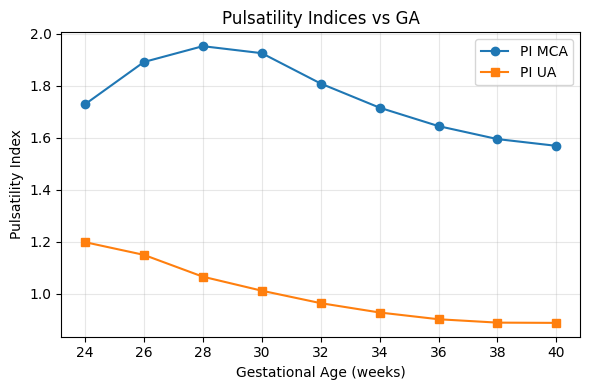

In [97]:
# ======================
# PI vs GA
# ======================
plt.figure(figsize=(6,4))
plt.plot(GA_list, df_outputs["PI_MCA"], 'o-', label="PI MCA")
plt.plot(GA_list, df_outputs["PI_UA"], 's-', label="PI UA")

plt.xlabel("Gestational Age (weeks)")
plt.ylabel("Pulsatility Index")
plt.title("Pulsatility Indices vs GA")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [98]:
# ======================
# velocities
# ======================

# DIAMETERS UA & UV: 10.3109/01443615.2011.647129
# DIAMETERS DV: 10.31729/jnma.3042 (until 33 weeks)
# DIAMETERS MCA: 10.55782/ane-2009-1735
# MPA, RPA, LPA:  https://doi.org/10.7863/jum.2007.26.3.309
# DIAMETER AORTA DN PA: https://doi.org/10.2214/ajr.149.5.1003


## 9. Time traces and PV loops


In [99]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import math

norm = mcolors.Normalize(vmin=min(GA_list), vmax=max(GA_list))
cmap = cm.coolwarm


def plot_subplots(results, GA_list, variables, titles, ylabel, pdf, ncols=3, GA_filter=None, ylim_dict=None):

    n = len(variables)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows))
    axes = axes.flatten()

    for i, var in enumerate(variables):
        ax = axes[i]

        for GA in GA_list:

            if GA_filter and not GA_filter(GA):
                continue

            color = cmap(norm(GA))
            ax.plot(results[GA]["t_norm"], results[GA][var], color=color, label=str(GA))

        ax.set_title(titles[i])
        ax.set_xlabel("Normalized cardiac cycle")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        
        if ylim_dict is not None and var in ylim_dict:
            ax.set_ylim(ylim_dict[var])

    # eliminar axes buits
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    # one legend for all subplots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")

    plt.tight_layout()
    pdf.savefig()
    plt.show()
    plt.close()


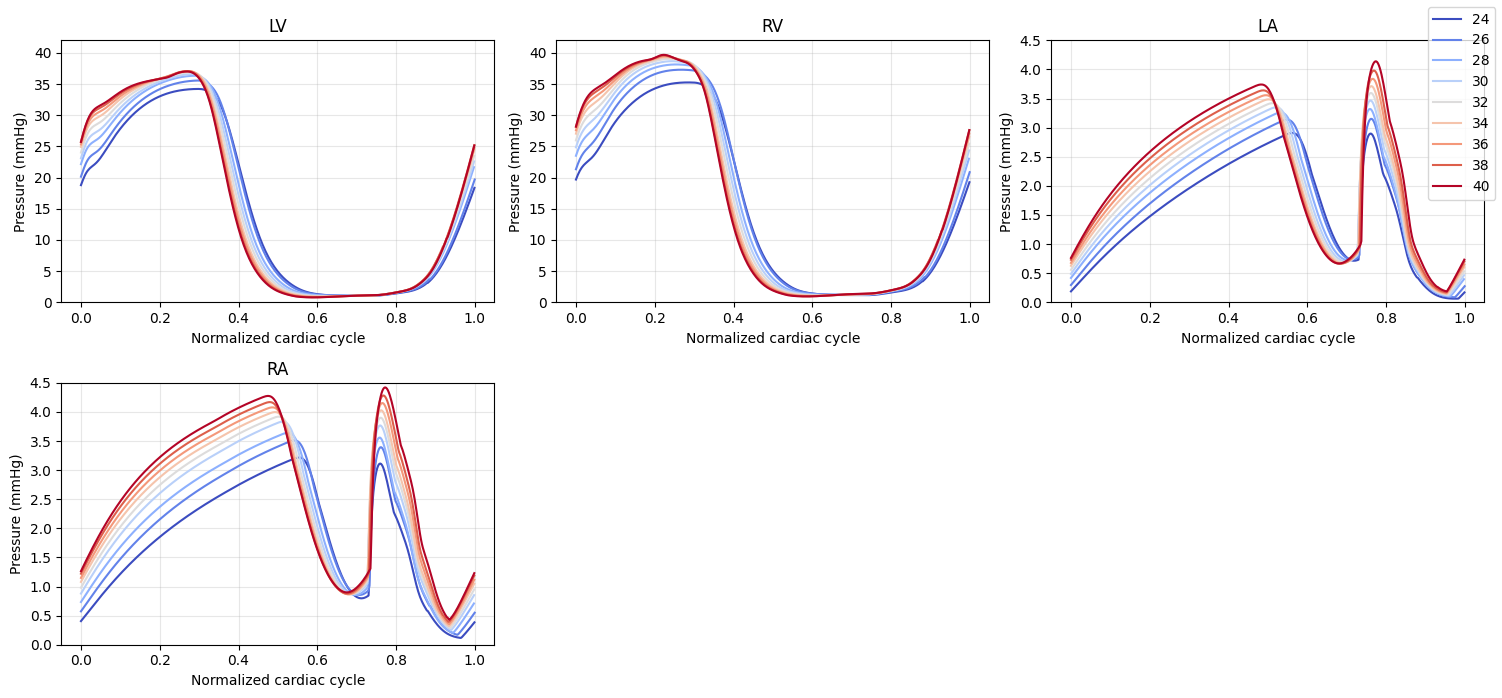

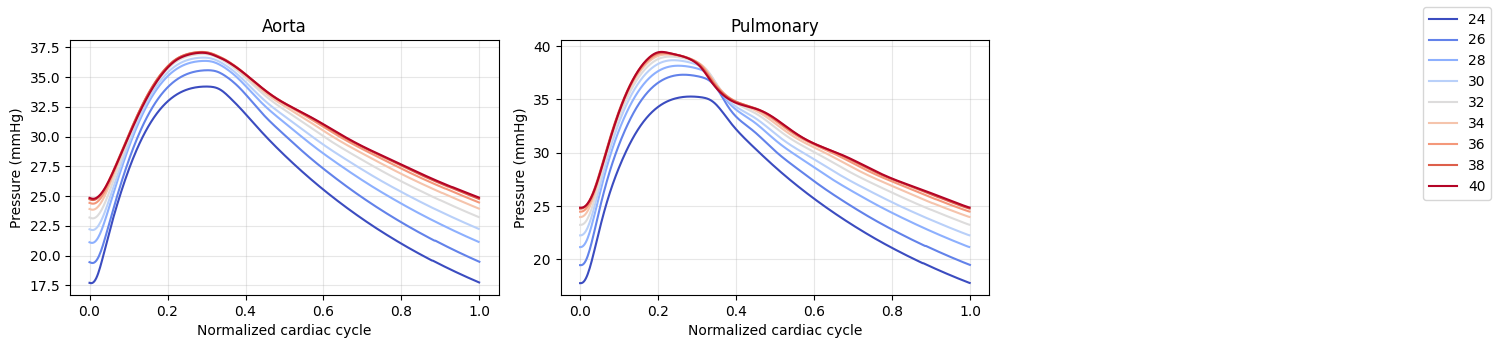

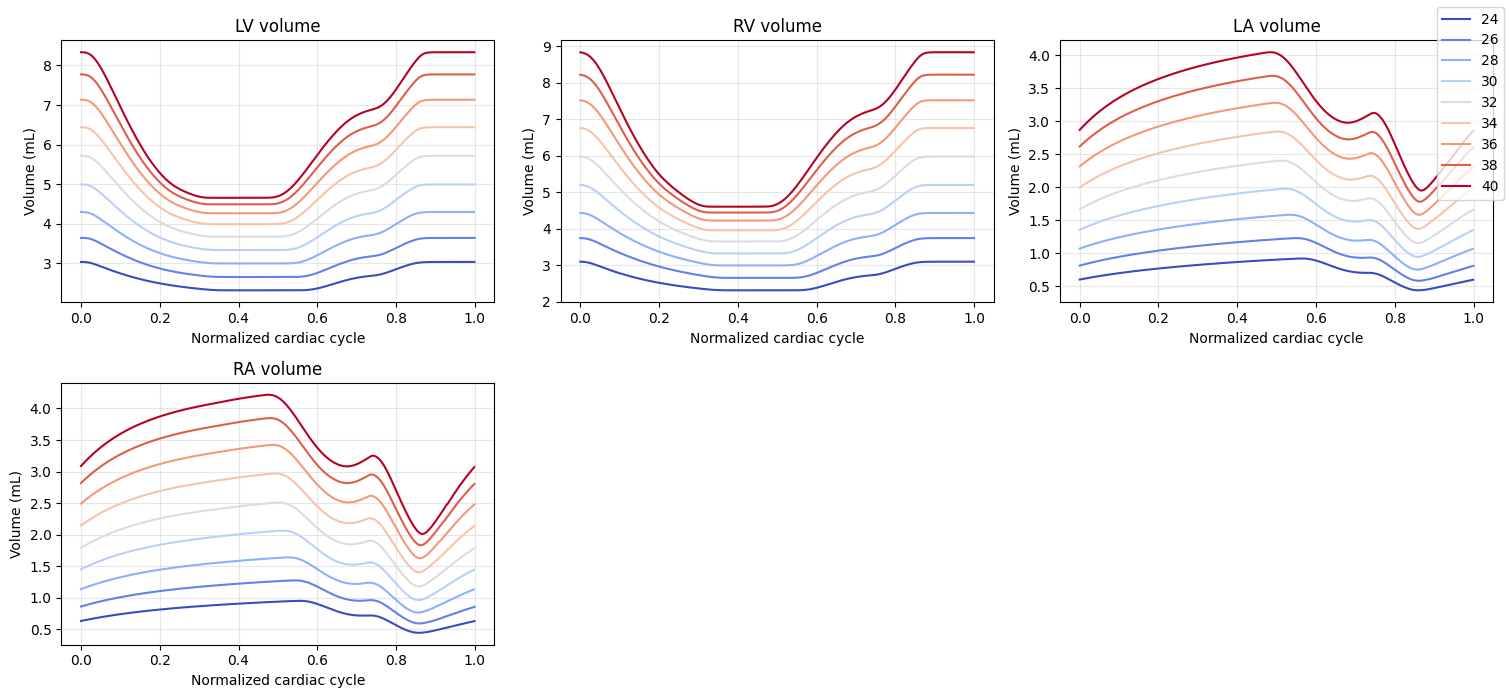

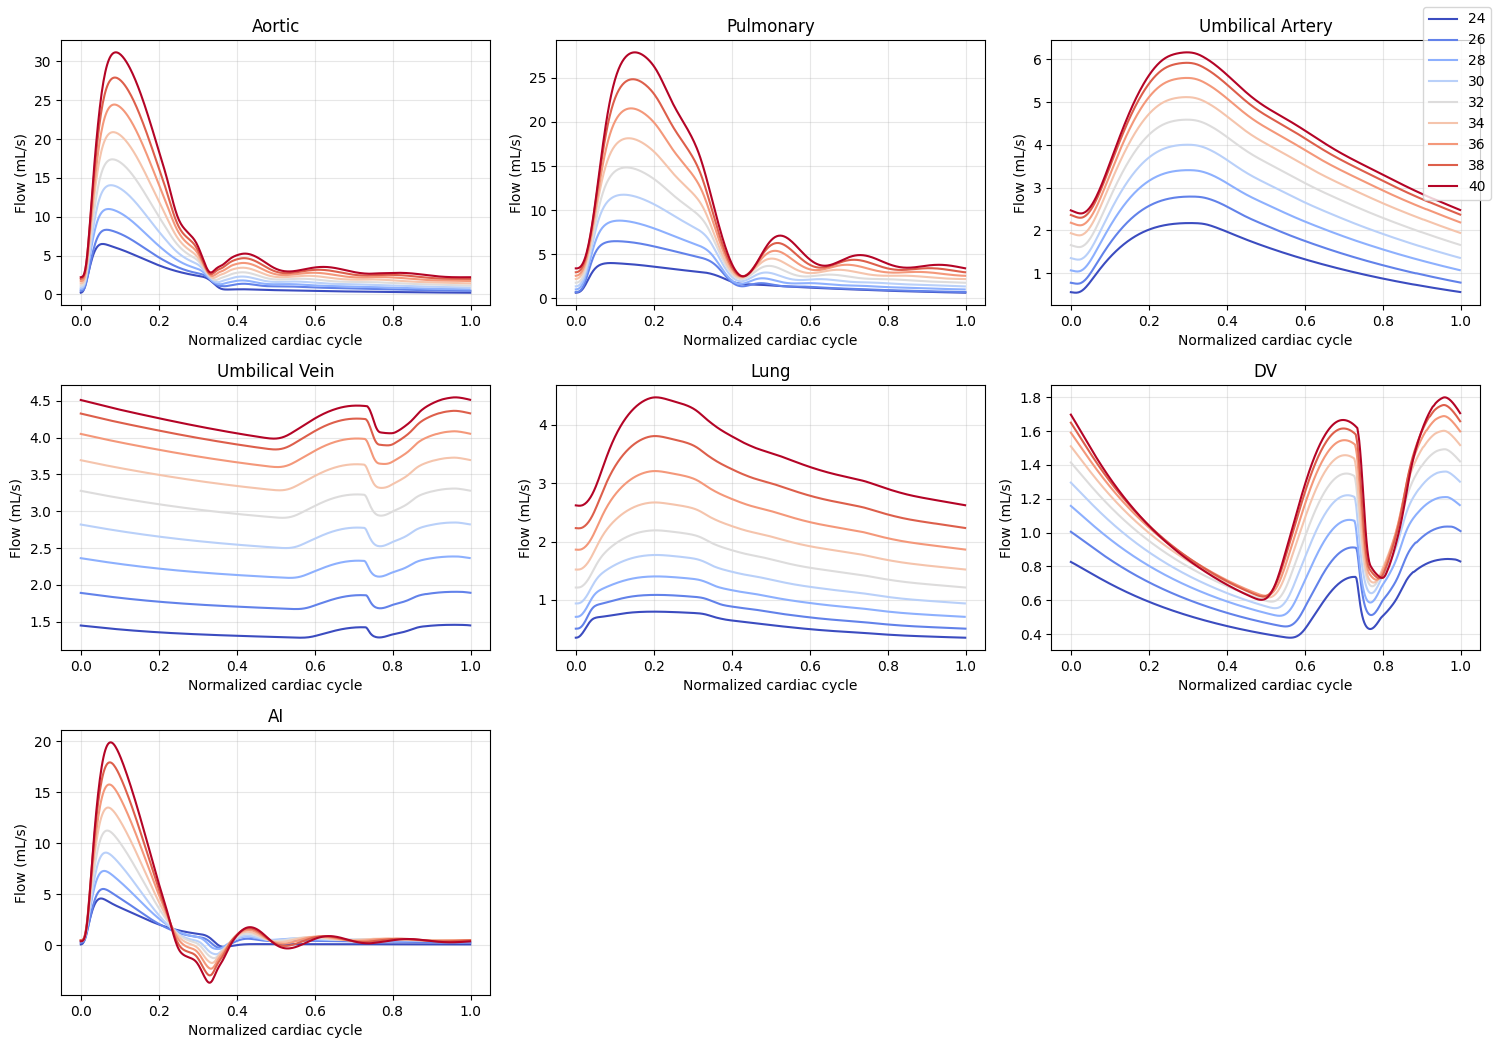

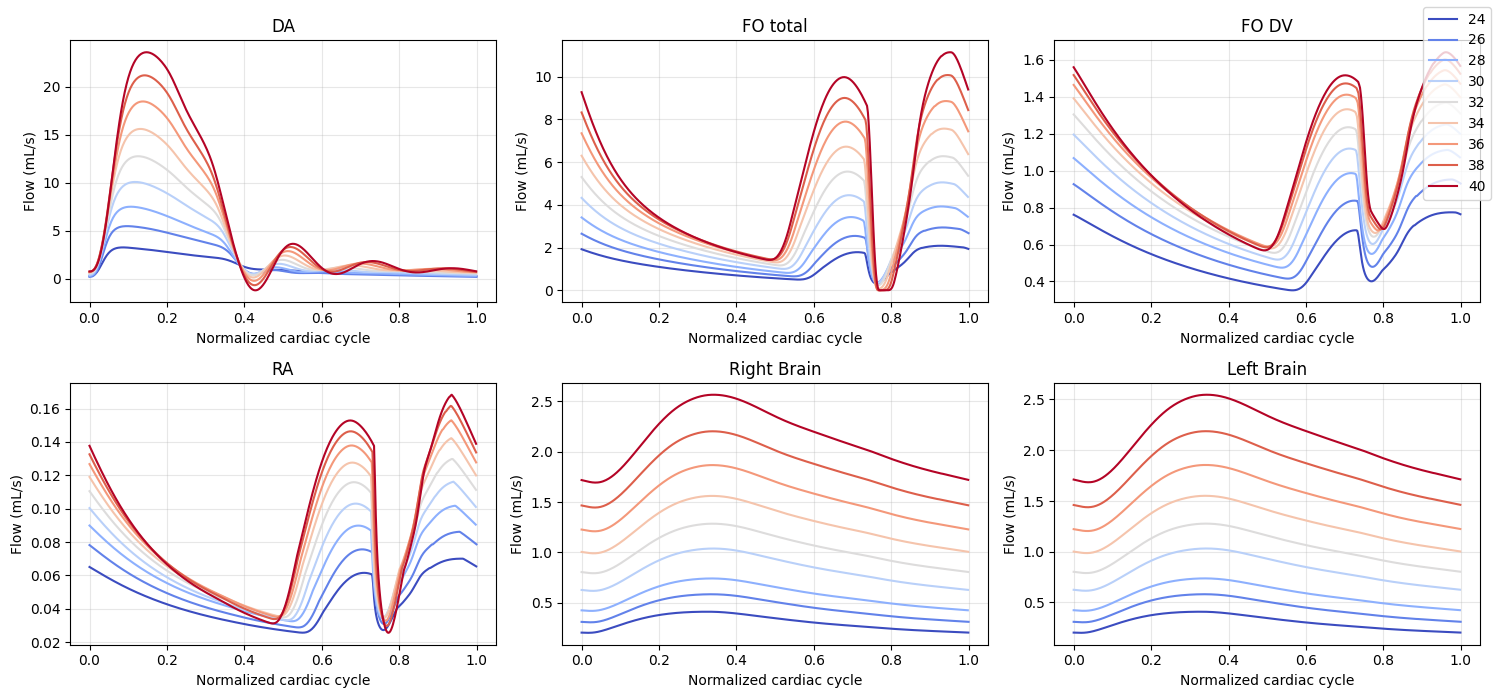

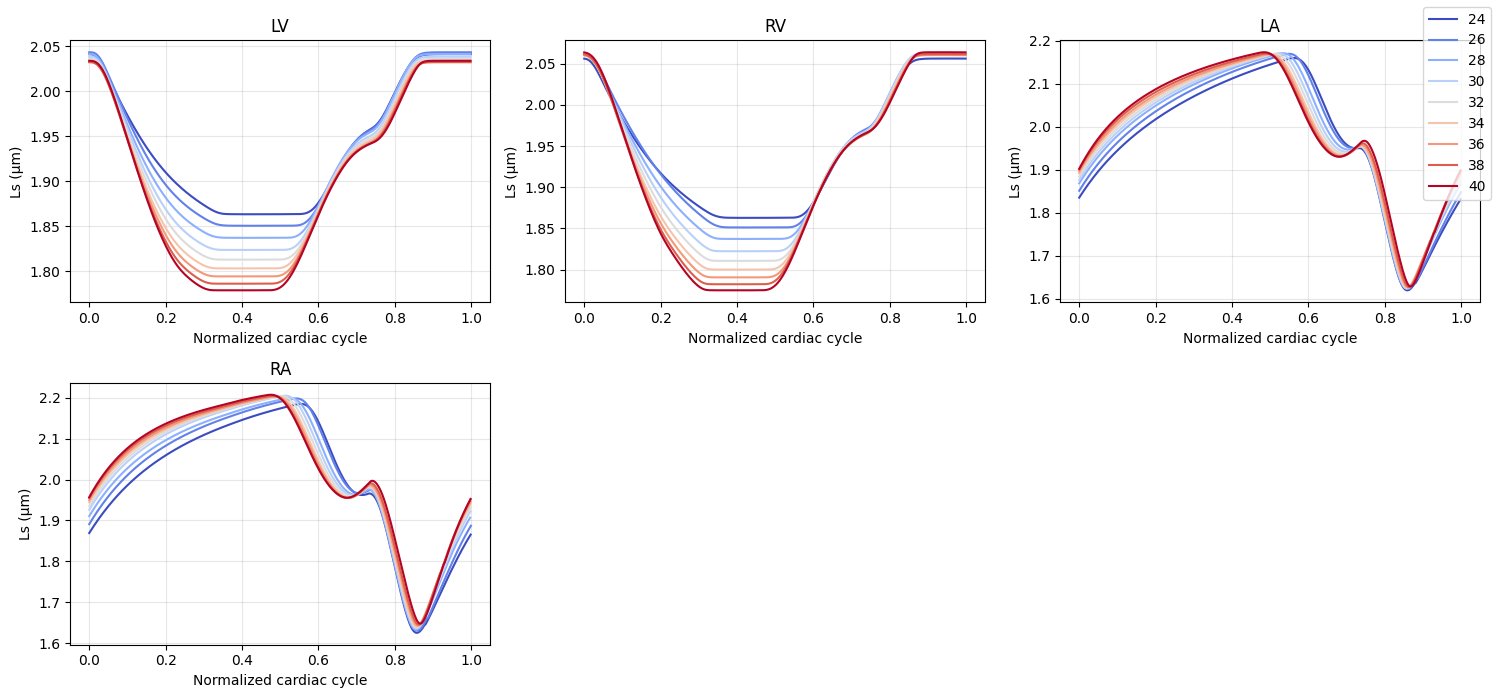

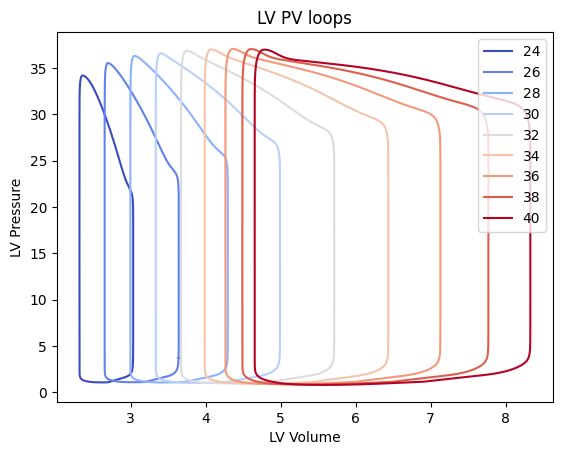

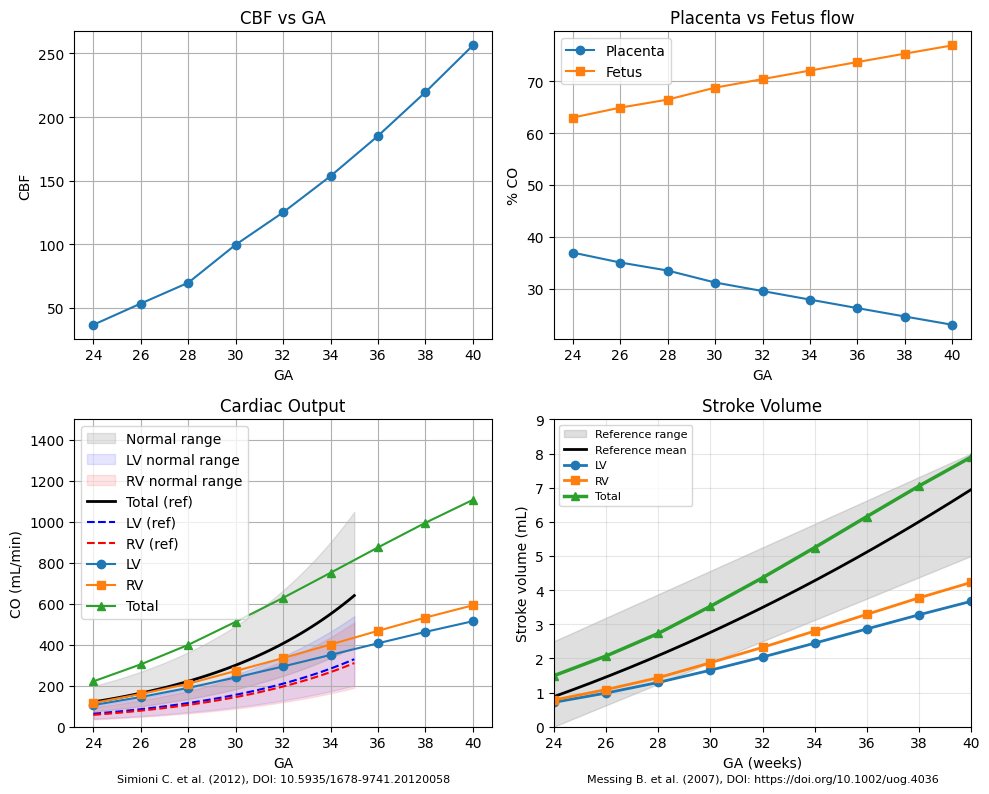

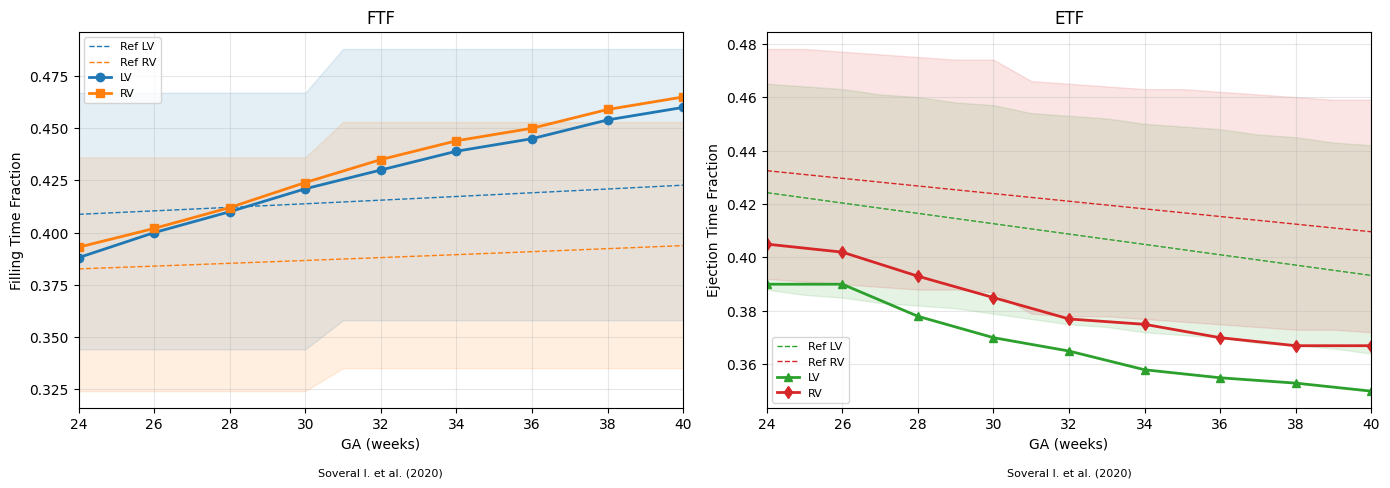

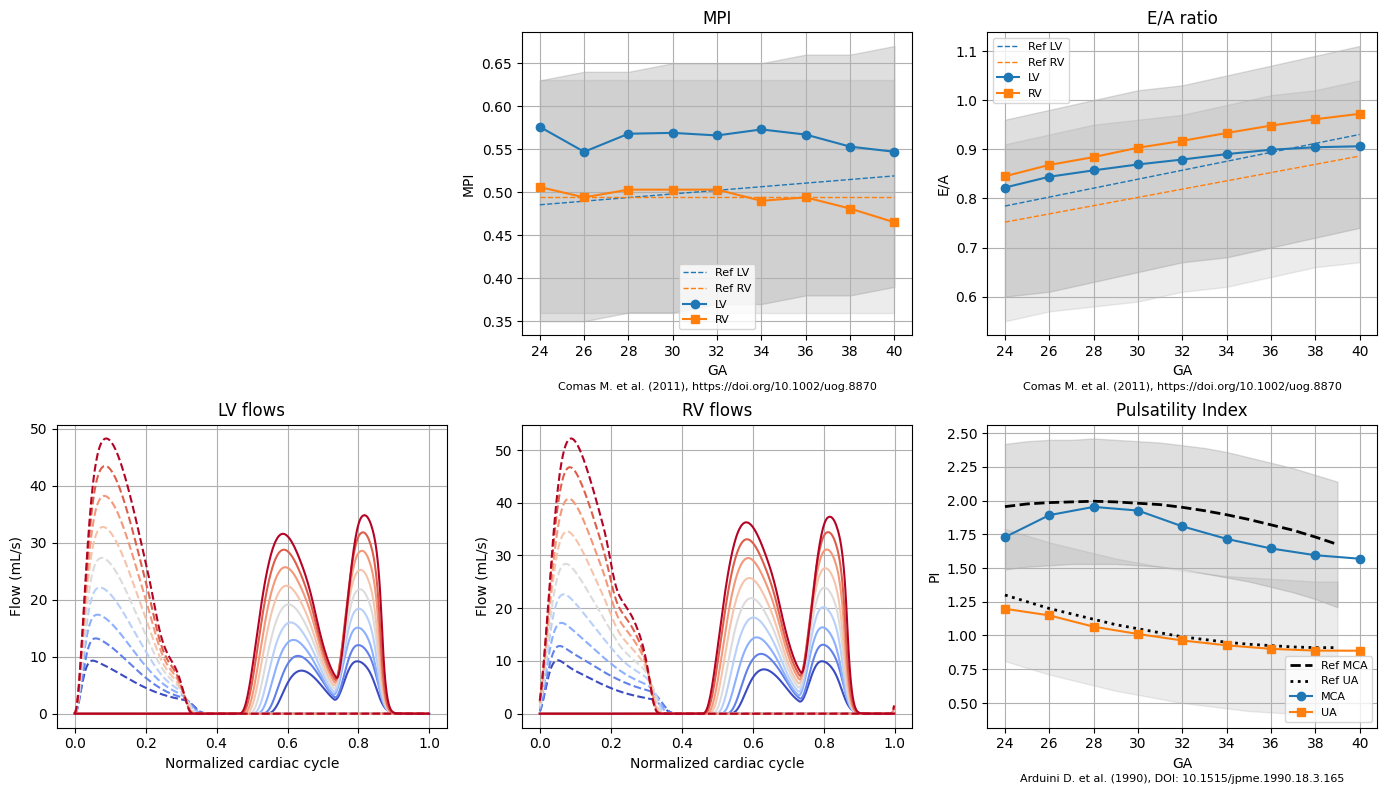

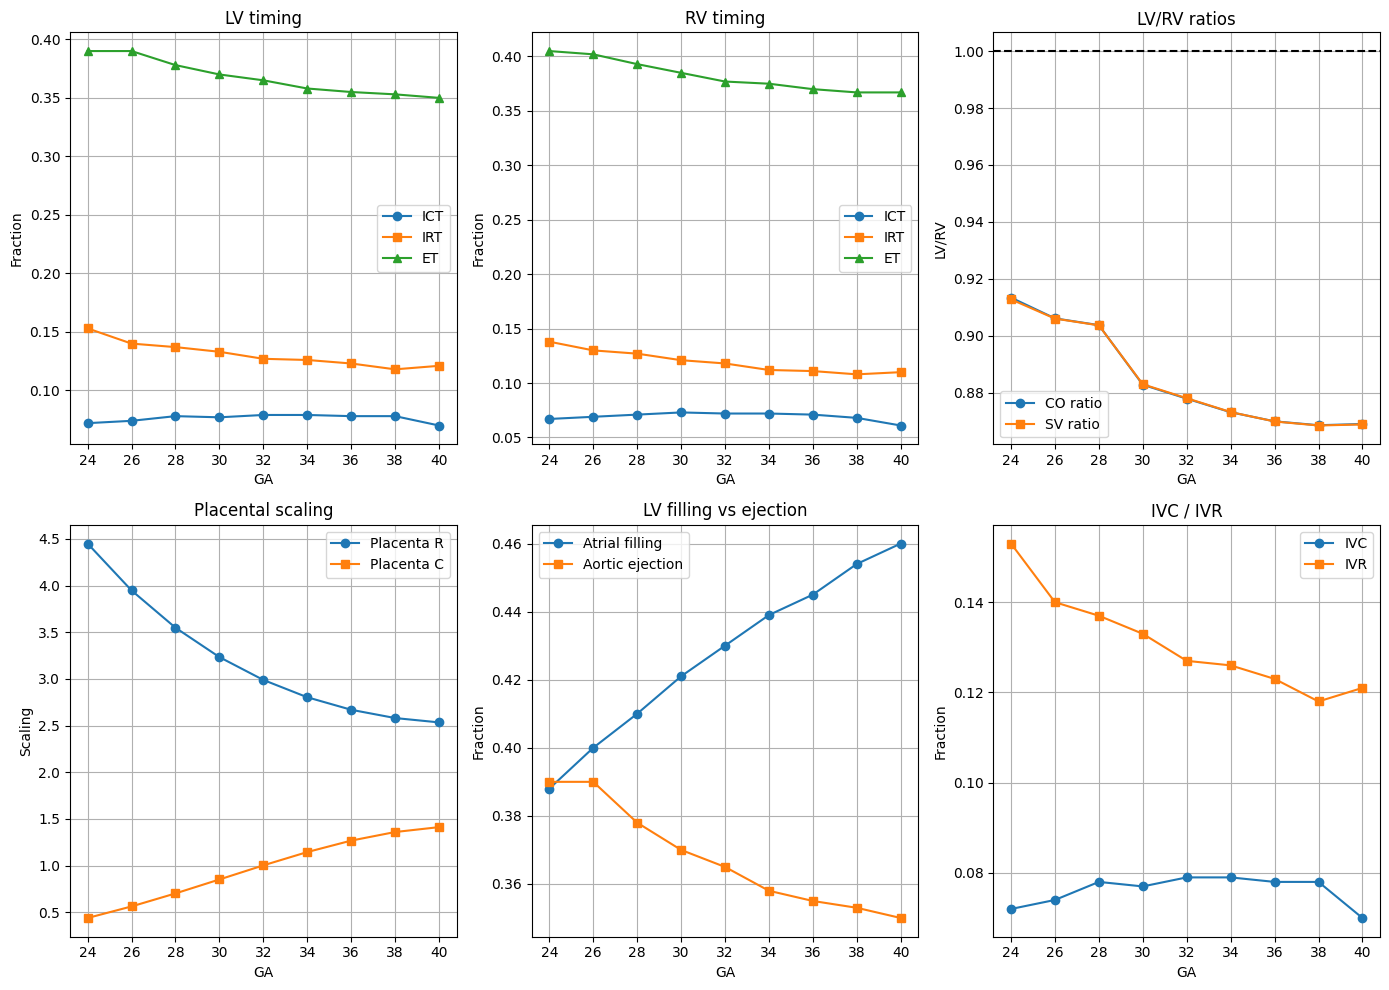

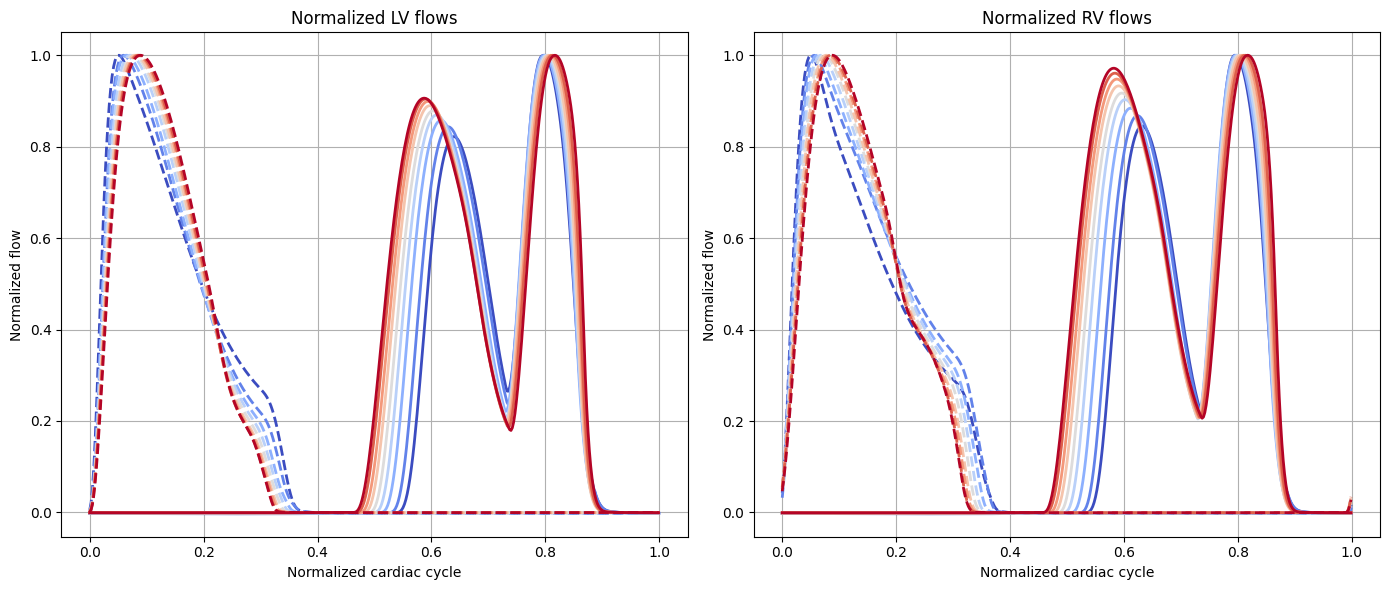

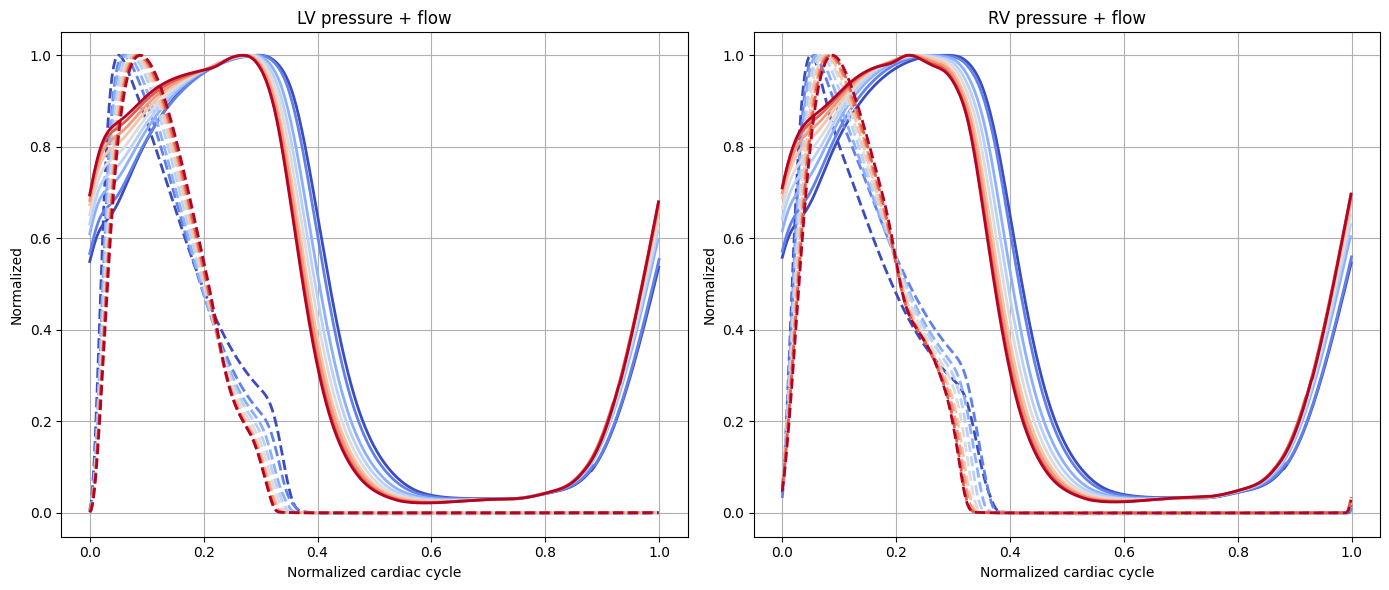

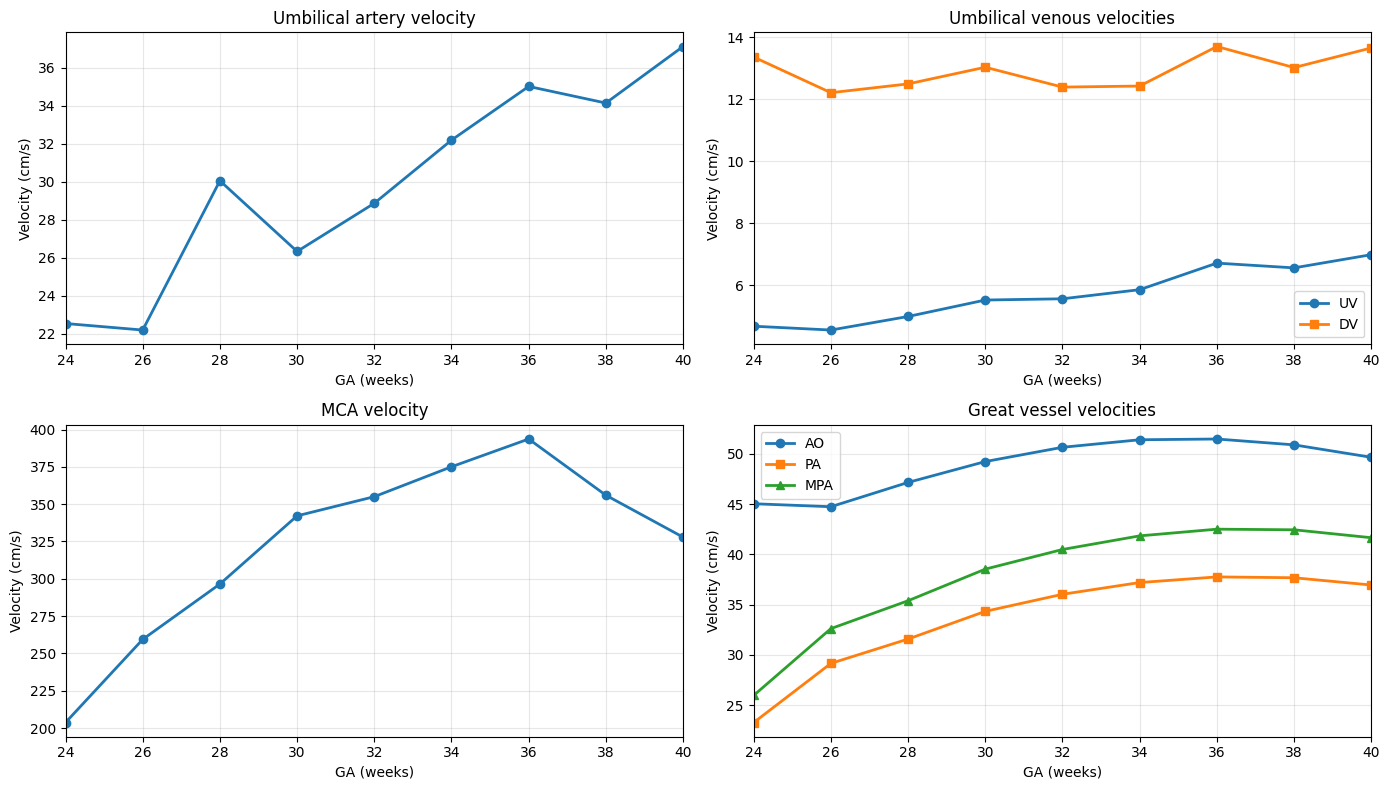

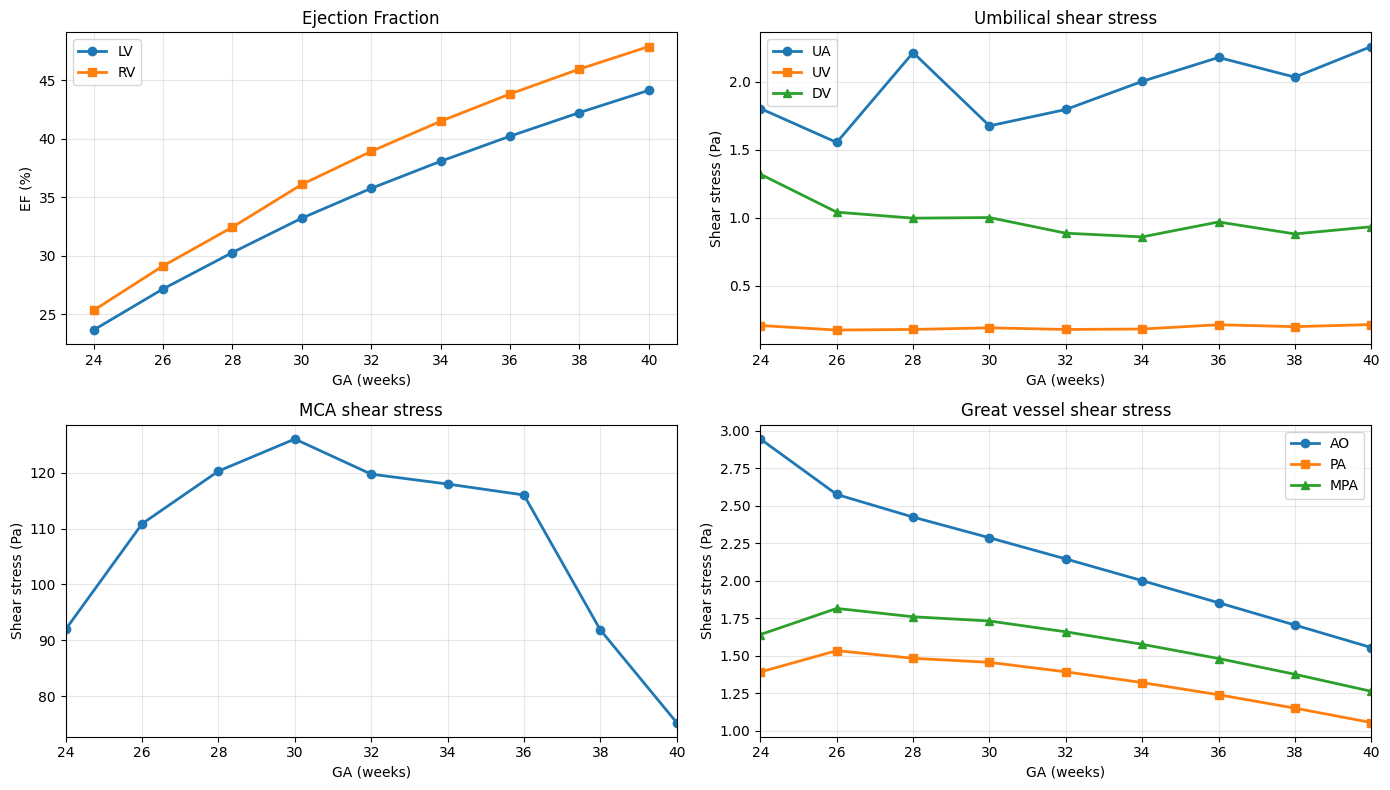

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

with PdfPages("fetal_results_fw_mixed_2.pdf") as pdf:

    # CARDIAC PRESSURES
    pressure_limits = {"P_LV_align": (0, 42),"P_RV_align": (0, 42),"P_LA_align": (0, 4.5),"P_RA_align": (0, 4.5)}
    plot_subplots(results, GA_list, variables=["P_LV_align", "P_RV_align", "P_LA_align", "P_RA_align"], titles=["LV", "RV", "LA", "RA"], ylabel="Pressure (mmHg)", pdf=pdf, ylim_dict=pressure_limits)
    plot_subplots(results, GA_list, variables=["P_AO_align", "P_MPA_align"], titles=["Aorta", "Pulmonary"], ylabel="Pressure (mmHg)", pdf=pdf)

    # VOLUMES
    plot_subplots(results, GA_list, variables=["V_LV_align", "V_RV_align", "V_LA_align", "V_RA_align"], titles=["LV volume", "RV volume", "LA volume", "RA volume"], ylabel="Volume (mL)", pdf=pdf)

    # FLOWS
    plot_subplots(results, GA_list, variables=["Q_AA_align", "Q_PA_align", "Q_UA_align", "Q_UV_align", "Q_lung_align", "Q_DV_align", "Q_AI_align"], titles=["Aortic", "Pulmonary", "Umbilical Artery", "Umbilical Vein", "Lung", "DV", "AI"], ylabel="Flow (mL/s)", pdf=pdf)

    # SHUNTS
    plot_subplots(results, GA_list, variables=["Q_DA_align", "Q_FO_align", "Q_FO2_align", "Q_RA_align", "Q_BR_R_align", "Q_BR_L_align"], titles=["DA", "FO total", "FO DV", "RA", "Right Brain", "Left Brain"], ylabel="Flow (mL/s)", pdf=pdf)

    # SARCOMERE
    plot_subplots(results, GA_list, variables=["LS_LV_align", "LS_RV_align", "LS_LA_align", "LS_RA_align"], titles=["LV", "RV", "LA", "RA"], ylabel="Ls (µm)", pdf=pdf) 

    # ======================
    # PV LOOP
    # ======================
    plt.figure()
    for GA in GA_list:
        color = cmap(norm(GA))
        plt.plot(results[GA]["V_LV"], results[GA]["P_LV"], color=color, label=str(GA))
    plt.xlabel("LV Volume")
    plt.ylabel("LV Pressure")
    plt.title("LV PV loops")
    plt.legend()
    pdf.savefig()
    plt.show()
    plt.close()
    
    plt.figure(figsize=(10, 8))
    # ======================
    # CBF
    # ======================
    plt.subplot(2, 2, 1)
    plt.plot(GA_list, [results[g]["CBF"] for g in GA_list], "o-")
    plt.xlabel("GA")
    plt.ylabel("CBF")
    plt.title("CBF vs GA")
    plt.grid()

    # ======================
    # PLACENTA vs FETUS
    # ======================
    plt.subplot(2, 2, 2)
    plt.plot(GA_list, [results[g]["Perc_Placenta"] for g in GA_list], "o-", label="Placenta")
    plt.plot(GA_list, [results[g]["Perc_Fetus"] for g in GA_list], "s-", label="Fetus")
    plt.xlabel("GA")
    plt.ylabel("% CO")
    plt.title("Placenta vs Fetus flow")
    plt.legend()
    plt.grid()

    # ======================
    # CO
    # ======================
    plt.subplot(2, 2, 3)

    GA_ref = np.linspace(24, 35, 50)

    # LV
    co_lv_p5  = np.array([37.41,44.27,51.53,59.19,67.26,75.72,84.58,93.85,103.52,113.59])
    co_lv_p50 = np.array([101.40,116.59,132.61,149.47,167.16,185.69,205.05,225.26,246.29,268.17])
    co_lv_p95 = np.array([165.39,188.90,213.68,239.74,267.06,295.66,325.52,356.66,389.07,422.74])

    # RV
    co_rv_p5  = np.array([35.44,41.77,48.48,55.55,62.99,70.80,78.98,87.53,96.44,105.72])
    co_rv_p50 = np.array([101.65,118.25,135.78,154.26,173.67,194.03,215.32,237.56,260.73,284.84])
    co_rv_p95 = np.array([167.86,194.72,223.09,252.96,284.35,317.25,351.66,387.59,425.02,463.96])

    # TOTAL
    co_tot_p5  = np.array([99.83,118.32,137.90,158.56,180.30,203.13,227.04,252.04,278.13,305.30])
    co_tot_p50 = np.array([204.96,237.08,271.00,306.72,344.23,383.53,424.63,467.53,512.22,558.71])
    co_tot_p95 = np.array([310.09,355.84,404.11,454.88,508.15,563.93,622.22,683.01,746.31,812.12])

    co_lv_mean = 1.729 * np.exp(0.150 * GA_ref)
    co_rv_mean = 1.467 * np.exp(0.153 * GA_ref)

    co_tot_mean = co_lv_mean + co_rv_mean

    sigma = 0.3

    def band(mean):
        return mean * np.exp(-1.645*sigma), mean * np.exp(1.645*sigma)
    
    co_lv_p5, co_lv_p95 = band(co_lv_mean)
    co_rv_p5, co_rv_p95 = band(co_rv_mean)
    co_tot_p5, co_tot_p95 = band(co_tot_mean)


    plt.fill_between(GA_ref, co_tot_p5, co_tot_p95,
                 color='gray', alpha=0.2, label='Normal range')

    plt.fill_between(GA_ref, co_lv_p5, co_lv_p95,
                 color='blue', alpha=0.1, label='LV normal range')

    plt.fill_between(GA_ref, co_rv_p5, co_rv_p95,
                 color='red', alpha=0.1, label='RV normal range')

    plt.plot(GA_ref, co_tot_mean, 'k-', lw=2, label='Total (ref)')
    plt.plot(GA_ref, co_lv_mean, 'b--', lw=1.5, label='LV (ref)')
    plt.plot(GA_ref, co_rv_mean, 'r--', lw=1.5, label='RV (ref)')

    plt.plot(GA_list, df_outputs["CO_LV"], '-o', label='LV')
    plt.plot(GA_list, df_outputs["CO_RV"], '-s', label='RV')
    plt.plot(GA_list, df_outputs["CardiacOutput"], '-^', label='Total')
    plt.xlabel("GA")
    plt.ylabel("CO (mL/min)")
    plt.ylim(0, 1500)
    plt.title("Cardiac Output")
    plt.legend()
    plt.grid()
    ax = plt.gca()
    ax.text(0.5, -0.18, "Simioni C. et al. (2012), DOI: 10.5935/1678-9741.20120058", transform=ax.transAxes,ha='center',fontsize=8)


    # ======================
    # SV
    # ======================

    plt.subplot(2, 2, 4)

    GA_ref = np.linspace(24, 40, 200)

    # Mean extracted from paper
    GA_mean_pts = np.array([
        24, 26, 28, 30, 32,
        34, 36, 38, 40
    ])

    SV_mean_pts = np.array([
        0.9, 1.5, 2.0, 2.7, 3.5,
        4.3, 5.2, 6.0, 6.9
    ])

    # 5th percentile
    GA_p5_pts = np.array([24, 40])
    SV_p5_pts = np.array([0.0, 5.0])

    # 95th percentile
    GA_p95_pts = np.array([24, 40])
    SV_p95_pts = np.array([2.5, 8.0])

    # Fits
    coef_mean = np.polyfit(GA_mean_pts, SV_mean_pts, 2)
    coef_p5   = np.polyfit(GA_p5_pts, SV_p5_pts, 1)
    coef_p95  = np.polyfit(GA_p95_pts, SV_p95_pts, 1)

    sv_tot_mean = np.polyval(coef_mean, GA_ref)
    sv_tot_p5   = np.polyval(coef_p5, GA_ref)
    sv_tot_p95  = np.polyval(coef_p95, GA_ref)

    plt.fill_between(
        GA_ref,
        sv_tot_p5,
        sv_tot_p95,
        color='gray',
        alpha=0.25,
        label='Reference range'
    )

    plt.plot(
        GA_ref,
        sv_tot_mean,
        'k-',
        lw=2,
        label='Reference mean'
    )

    plt.plot(
        GA_list,
        df_outputs["SV_LV"],
        '-o',
        linewidth=2,
        label='LV'
    )

    plt.plot(
        GA_list,
        df_outputs["SV_RV"],
        '-s',
        linewidth=2,
        label='RV'
    )

    plt.plot(
        GA_list,
        df_outputs["C_SV"],
        '-^',
        linewidth=2.5,
        label='Total'
    )

    plt.xlim(24, 40)

    plt.xlabel("GA (weeks)")
    plt.ylabel("Stroke volume (mL)")
    plt.title("Stroke Volume")
    plt.ylim(0, 9)

    plt.grid(alpha=0.3)

    plt.legend(fontsize=8)

    ax = plt.gca()

    ax.text(
        0.5,
        -0.18,
        "Messing B. et al. (2007), DOI: https://doi.org/10.1002/uog.4036",
        transform=ax.transAxes,
        ha='center',
        fontsize=8
    )

    # ======================
    plt.tight_layout()

    pdf.savefig()
    plt.show()
    plt.close()

        # =====================================================
    # FTF + ETF
    # =====================================================

    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # =====================================================
    # FTF
    # =====================================================

    ax = axes[0]

    ga_ref = np.arange(24, 41)

    hr_ref = np.array([
        fetal_heart_rate(g)
        for g in ga_ref
    ])

    # -----------------------------------
    # FTF reference equations
    # -----------------------------------

    ftf_lv_ref = (
        16.42995632288723 +
        (3617.924450406454 / hr_ref)
    ) / 100.0

    ftf_rv_ref = (
        18.73327596623064 +
        (2889.916516631465 / hr_ref)
    ) / 100.0

    # -----------------------------------
    # FTF normal ranges
    # -----------------------------------

    lv_ftf_p5_150  = 34.4 / 100
    lv_ftf_p95_150 = 46.7 / 100

    rv_ftf_p5_150  = 32.4 / 100
    rv_ftf_p95_150 = 43.6 / 100

    lv_ftf_p5_140  = 35.8 / 100
    lv_ftf_p95_140 = 48.8 / 100

    rv_ftf_p5_140  = 33.5 / 100
    rv_ftf_p95_140 = 45.3 / 100

    lv_ftf_p5 = np.array([
        lv_ftf_p5_150 if g <= 30 else lv_ftf_p5_140
        for g in ga_ref
    ])

    lv_ftf_p95 = np.array([
        lv_ftf_p95_150 if g <= 30 else lv_ftf_p95_140
        for g in ga_ref
    ])

    rv_ftf_p5 = np.array([
        rv_ftf_p5_150 if g <= 30 else rv_ftf_p5_140
        for g in ga_ref
    ])

    rv_ftf_p95 = np.array([
        rv_ftf_p95_150 if g <= 30 else rv_ftf_p95_140
        for g in ga_ref
    ])

    # -----------------------------------
    # Normal bands
    # -----------------------------------

    ax.fill_between(
        ga_ref,
        lv_ftf_p5,
        lv_ftf_p95,
        color='tab:blue',
        alpha=0.12
    )

    ax.fill_between(
        ga_ref,
        rv_ftf_p5,
        rv_ftf_p95,
        color='tab:orange',
        alpha=0.12
    )

    # -----------------------------------
    # Reference lines
    # -----------------------------------

    ax.plot(
        ga_ref,
        ftf_lv_ref,
        '--',
        color='tab:blue',
        lw=1,
        label='Ref LV'
    )

    ax.plot(
        ga_ref,
        ftf_rv_ref,
        '--',
        color='tab:orange',
        lw=1,
        label='Ref RV'
    )

    # -----------------------------------
    # Model outputs
    # -----------------------------------

    mask = (
        (np.array(GA_list) >= 24) &
        (np.array(GA_list) <= 40)
    )

    ga_plot = np.array(GA_list)[mask]

    ax.plot(
        ga_plot,
        np.array(df_outputs["FTF_LV"])[mask],
        '-o',
        color='tab:blue',
        lw=2,
        label='LV'
    )

    ax.plot(
        ga_plot,
        np.array(df_outputs["FTF_RV"])[mask],
        '-s',
        color='tab:orange',
        lw=2,
        label='RV'
    )

    ax.set_xlabel("GA (weeks)")

    ax.set_ylabel("Filling Time Fraction")

    ax.set_title("FTF")

    ax.set_xlim(24, 40)

    ax.grid(alpha=0.3)

    ax.legend(fontsize=8)

    ax.text(
        0.5,
        -0.18,
        "Soveral I. et al. (2020)",
        transform=ax.transAxes,
        ha='center',
        fontsize=8
    )

    # =====================================================
    # ETF
    # =====================================================

    ax = axes[1]

    # -----------------------------------
    # ETF reference equations
    # -----------------------------------

    etf_lv_ref = (
        29.692919 +
        (0.108611 * hr_ref) -
        (0.139257 * ga_ref)
    ) / 100.0

    etf_rv_ref = (
        26.748934 +
        (0.124522 * hr_ref) -
        (0.080492 * ga_ref)
    ) / 100.0

    # -----------------------------------
    # ETF normal ranges
    # -----------------------------------

    lv_etf_p5_150 = np.array([
        38.8,38.6,38.5,38.3,38.2,38.1,37.9
    ])

    lv_etf_p95_150 = np.array([
        46.5,46.4,46.3,46.1,46.0,45.8,45.7
    ])

    lv_etf_p5_140 = np.array([
        37.7,37.5,37.4,37.2,37.1,
        37.0,36.8,36.7,36.6,36.4
    ])

    lv_etf_p95_140 = np.array([
        45.4,45.3,45.2,45.0,44.9,
        44.8,44.6,44.5,44.3,44.2
    ])

    rv_etf_p5_150 = np.array([
        39.2,39.1,39.0,38.9,38.8,38.8,38.7
    ])

    rv_etf_p95_150 = np.array([
        47.8,47.8,47.7,47.6,47.5,47.4,47.4
    ])

    rv_etf_p5_140 = np.array([
        37.9,37.8,37.8,37.7,37.6,
        37.5,37.4,37.3,37.3,37.2
    ])

    rv_etf_p95_140 = np.array([
        46.6,46.5,46.4,46.3,46.3,
        46.2,46.1,46.0,45.9,45.9
    ])

    lv_etf_p5 = np.concatenate([
        lv_etf_p5_150,
        lv_etf_p5_140
    ]) / 100

    lv_etf_p95 = np.concatenate([
        lv_etf_p95_150,
        lv_etf_p95_140
    ]) / 100

    rv_etf_p5 = np.concatenate([
        rv_etf_p5_150,
        rv_etf_p5_140
    ]) / 100

    rv_etf_p95 = np.concatenate([
        rv_etf_p95_150,
        rv_etf_p95_140
    ]) / 100

    # -----------------------------------
    # Normal bands
    # -----------------------------------

    ax.fill_between(
        ga_ref,
        lv_etf_p5,
        lv_etf_p95,
        color='tab:green',
        alpha=0.12
    )

    ax.fill_between(
        ga_ref,
        rv_etf_p5,
        rv_etf_p95,
        color='tab:red',
        alpha=0.12
    )

    # -----------------------------------
    # Reference lines
    # -----------------------------------

    ax.plot(
        ga_ref,
        etf_lv_ref,
        '--',
        color='tab:green',
        lw=1,
        label='Ref LV'
    )

    ax.plot(
        ga_ref,
        etf_rv_ref,
        '--',
        color='tab:red',
        lw=1,
        label='Ref RV'
    )

    # -----------------------------------
    # Model outputs
    # -----------------------------------

    ax.plot(
        ga_plot,
        np.array(df_outputs["ETF_LV"])[mask],
        '-^',
        color='tab:green',
        lw=2,
        label='LV'
    )

    ax.plot(
        ga_plot,
        np.array(df_outputs["ETF_RV"])[mask],
        '-d',
        color='tab:red',
        lw=2,
        label='RV'
    )

    ax.set_xlabel("GA (weeks)")

    ax.set_ylabel("Ejection Time Fraction")

    ax.set_title("ETF")

    ax.set_xlim(24, 40)

    ax.grid(alpha=0.3)

    ax.legend(fontsize=8)

    ax.text(
        0.5,
        -0.18,
        "Soveral I. et al. (2020)",
        transform=ax.transAxes,
        ha='center',
        fontsize=8
    )

    # =====================================================

    plt.tight_layout()

    pdf.savefig()

    plt.show()

    plt.close()


    # =====================================================
    # MPI + EA + PI
    # =====================================================

    plt.figure(figsize=(14,8))
    

    # ======================
    # MPI
    # ======================
    plt.subplot(2, 3, 2)
    GA_days = np.array(GA_list) * 7

    # Literature normals
    mpi_lv_ref = 0.435 + 0.0003 * GA_days
    mpi_rv_ref = np.full(len(GA_list), 0.4943)
    
    mpi_p95_lv = np.array([0.63, 0.64, 0.64, 0.65, 0.65, 0.65, 0.66, 0.66, 0.67])
    mpi_p5_lv = np.array([0.35, 0.35, 0.36, 0.36, 0.37, 0.37, 0.38, 0.38, 0.39])
    mpi_p95_lv_i = np.interp(GA_list, GA_list, mpi_p95_lv)
    mpi_p5_lv_i  = np.interp(GA_list, GA_list, mpi_p5_lv)
    mpi_p5_rv = np.full_like(GA_list, 0.36, dtype=float)
    mpi_p95_rv = np.full_like(GA_list, 0.63, dtype=float)

    plt.fill_between(GA_list, mpi_p5_lv_i, mpi_p95_lv_i, color='gray', alpha=0.25)

    plt.fill_between(GA_list, mpi_p5_rv, mpi_p95_rv, color='gray', alpha=0.15)

    lv_color = 'tab:blue'
    rv_color = 'tab:orange'

    # black lines
    plt.plot(GA_list, mpi_lv_ref, '--',color=lv_color, lw=1, label='Ref LV')
    plt.plot(GA_list, mpi_rv_ref, '--', color=rv_color, lw=1, label='Ref RV')

    # model
    plt.plot(GA_list, df_outputs["MPI_LV"], '-o', color=lv_color, label='LV')
    plt.plot(GA_list, df_outputs["MPI_RV"], '-s', color=rv_color, label='RV')

    plt.xlabel("GA")
    plt.ylabel("MPI")
    plt.title("MPI")
    plt.legend(fontsize=8)
    plt.grid()

    ax = plt.gca()
    ax.text(0.5, -0.18, "Comas M. et al. (2011), https://doi.org/10.1002/uog.8870", transform=ax.transAxes,ha='center',fontsize=8)

    # ======================
    # E/A
    # ======================
    plt.subplot(2, 3, 3)
    GA_days = np.array(GA_list) * 7

    ea_lv_ref = 0.566 + 0.0013 * GA_days
    ea_rv_ref = 0.550 + 0.0012 * GA_days

    # Percentiles LV
    ea_p95_lv = np.array([0.96, 0.98, 1.00, 1.02, 1.03, 1.05, 1.07, 1.09, 1.11])
    ea_p5_lv  = np.array([0.60, 0.61, 0.63, 0.65, 0.67, 0.68, 0.70, 0.72, 0.74])

    # Percentiles RV
    ea_p95_rv = np.array([0.91, 0.93, 0.95, 0.96, 0.97, 0.99, 1.01, 1.02, 1.04])
    ea_p5_rv  = np.array([0.55, 0.57, 0.58, 0.59, 0.61, 0.62, 0.64, 0.66, 0.67])

    ea_p95_lv_i = np.interp(GA_list, GA_list, ea_p95_lv)
    ea_p5_lv_i  = np.interp(GA_list, GA_list, ea_p5_lv)

    ea_p95_rv_i = np.interp(GA_list, GA_list, ea_p95_rv)
    ea_p5_rv_i  = np.interp(GA_list, GA_list, ea_p5_rv)
    
    plt.fill_between(GA_list, ea_p5_lv_i, ea_p95_lv_i,
                 color='gray', alpha=0.25)
    plt.fill_between(GA_list, ea_p5_rv_i, ea_p95_rv_i,
                 color='gray', alpha=0.15)

    plt.plot(GA_list, ea_lv_ref, '--', color=lv_color, lw=1, label='Ref LV')
    plt.plot(GA_list, ea_rv_ref, '--', color=rv_color, lw=1, label='Ref RV')

    plt.plot(GA_list, df_outputs["EA_LV"], '-o', color=lv_color, label='LV')
    plt.plot(GA_list, df_outputs["EA_RV"], '-s', color=rv_color, label='RV')

    plt.xlabel("GA")
    plt.ylabel("E/A")
    plt.title("E/A ratio")
    plt.legend(fontsize=8)
    plt.grid()
    ax = plt.gca()
    ax.text(0.5, -0.18, "Comas M. et al. (2011), https://doi.org/10.1002/uog.8870", transform=ax.transAxes,ha='center',fontsize=8)

    # ======================
    # LV flows
    # ======================
    plt.subplot(2, 3, 4)
    for GA in GA_list:
        color = cmap(norm(GA))
        t = results[GA]["t_norm"]
        plt.plot(t,results[GA]["Q_MITRAL_align"],color=color)
        plt.plot(t,results[GA]["Q_AORTIC_align"],color=color,linestyle='--')
    plt.title("LV flows")
    plt.xlabel("Normalized cardiac cycle")
    plt.ylabel("Flow (mL/s)")
    plt.grid()

    # ======================
    # RV flows
    # ======================
    plt.subplot(2, 3, 5)
    for GA in GA_list:
        color = cmap(norm(GA))
        t = results[GA]["t_norm"]
        plt.plot(t, results[GA]["Q_TRICUSPID_align"], color=color)
        plt.plot(t, results[GA]["Q_PULMONARY_align"], linestyle='--', color=color)
    plt.title("RV flows")
    plt.xlabel("Normalized cardiac cycle")
    plt.ylabel("Flow (mL/s)")
    plt.grid()

    # ======================
    # PI
    # ======================
    plt.subplot(2, 3, 6)
    weeks_ref = np.arange(24, 40)


    # MCA reference ranges
    mca_low = np.array([
    1.49,1.51,1.52,1.53,1.53,1.53,1.52,1.51,1.49,
    1.46,1.43,1.40,1.36,1.32,1.27,1.21
    ])

    mca_high = np.array([
    2.42,2.44,2.45,2.45,2.46,2.45,2.44,2.43,2.41,
    2.39,2.36,2.32,2.28,2.24,2.19,2.14
    ])

    mca_mean = (mca_low + mca_high) / 2

    # UA reference ranges
    ua_low = np.array([
    0.81,0.76,0.71,0.67,0.63,0.59,0.56,0.53,0.50,
    0.48,0.46,0.44,0.43,0.42,0.42,0.42
    ])

    ua_high = np.array([
    1.79,1.74,1.69,1.65,1.61,1.57,1.54,1.51,1.48,
    1.46,1.44,1.43,1.42,1.41,1.40,1.40
    ])

    ua_mean = (ua_low + ua_high)/2

    # gray bands
    plt.fill_between(weeks_ref, mca_low, mca_high, color='gray', alpha=0.25)
    plt.fill_between(weeks_ref, ua_low, ua_high, color='gray', alpha=0.15)

    # black reference lines
    plt.plot(weeks_ref, mca_mean, 'k--', lw=2, label='Ref MCA')
    plt.plot(weeks_ref, ua_mean, 'k:', lw=2, label='Ref UA')

    # model
    plt.plot(GA_list, df_outputs["PI_MCA"], 'o-', label='MCA')
    plt.plot(GA_list, df_outputs["PI_UA"], 's-', label='UA')

    plt.title("Pulsatility Index")
    plt.xlabel("GA")
    plt.ylabel("PI")
    plt.legend(fontsize=8)
    plt.grid()
    ax = plt.gca()
    ax.text(0.5, -0.18, "Arduini D. et al. (1990), DOI: 10.1515/jpme.1990.18.3.165", transform=ax.transAxes,ha='center',fontsize=8)

    # ======================
    plt.tight_layout()

    pdf.savefig()
    plt.show()
    plt.close()

    # =====================================================
    # TIMING / RATIOS / PLACENTA
    # =====================================================
    plt.figure(figsize=(14, 10))

    # ======================
    # LV timing
    # ======================
    plt.subplot(2, 3, 1)

    plt.plot(GA_list, df_outputs["ICT_LV"], '-o', label='ICT')
    plt.plot(GA_list, df_outputs["IRT_LV"], '-s', label='IRT')
    plt.plot(GA_list, df_outputs["ET_LV"], '-^', label='ET')

    plt.xlabel("GA")
    plt.ylabel("Fraction")
    plt.title("LV timing")
    plt.grid()
    plt.legend()

    # ======================
    # RV timing
    # ======================
    plt.subplot(2, 3, 2)

    plt.plot(GA_list, df_outputs["ICT_RV"], '-o', label='ICT')
    plt.plot(GA_list, df_outputs["IRT_RV"], '-s', label='IRT')
    plt.plot(GA_list, df_outputs["ET_RV"], '-^', label='ET')

    plt.xlabel("GA")
    plt.ylabel("Fraction")
    plt.title("RV timing")
    plt.grid()
    plt.legend()

    # ======================
    # LV/RV ratios
    # ======================
    plt.subplot(2, 3, 3)

    lv_rv_co = np.array(df_outputs["CO_LV"]) / np.array(df_outputs["CO_RV"])
    lv_rv_sv = np.array(df_outputs["SV_LV"]) / np.array(df_outputs["SV_RV"])

    plt.plot(GA_list, lv_rv_co, '-o', label='CO ratio')
    plt.plot(GA_list, lv_rv_sv, '-s', label='SV ratio')

    plt.axhline(1.0, color='k', linestyle='--')

    plt.xlabel("GA")
    plt.ylabel("LV/RV")
    plt.title("LV/RV ratios")
    plt.grid()
    plt.legend()

    # ======================
    # Placenta scaling
    # ======================
    plt.subplot(2, 3, 4)

    plt.plot(GA_list, placenta_R_values, '-o', label='Placenta R')
    plt.plot(GA_list, placenta_C_values, '-s', label='Placenta C')

    plt.xlabel("GA")
    plt.ylabel("Scaling")
    plt.title("Placental scaling")
    plt.grid()
    plt.legend()

    # ======================
    # Atrial vs Aortic timing
    # ======================
    plt.subplot(2, 3, 5)

    plt.plot(GA_list, df_outputs["FTF_LV"], '-o', label='Atrial filling')
    plt.plot(GA_list, df_outputs["ET_LV"], '-s', label='Aortic ejection')

    plt.xlabel("GA")
    plt.ylabel("Fraction")
    plt.title("LV filling vs ejection")
    plt.grid()
    plt.legend()

    # ======================
    # IVC / IVR
    # ======================
    plt.subplot(2, 3, 6)

    plt.plot(GA_list, df_outputs["ICT_LV"], '-o', label='IVC')
    plt.plot(GA_list, df_outputs["IRT_LV"], '-s', label='IVR')

    plt.xlabel("GA")
    plt.ylabel("Fraction")
    plt.title("IVC / IVR")
    plt.grid()
    plt.legend()

    plt.tight_layout()

    pdf.savefig()
    plt.show()
    plt.close()


    # =====================================================
    # NORMALIZED FLOWS
    # =====================================================
    plt.figure(figsize=(14,6))

    # ======================
    # LV normalized
    # ======================
    plt.subplot(1,2,1)

    for GA in GA_list:

        color = cmap(norm(GA))

        t = results[GA]["t_norm"]
        q_m = results[GA]["Q_MITRAL_align"] / np.max(np.abs(results[GA]["Q_MITRAL_align"]))
        q_a = results[GA]["Q_AORTIC_align"] / np.max(np.abs(results[GA]["Q_AORTIC_align"]))
        plt.plot(t, q_m, color=color, linewidth=2)
        plt.plot(t,q_a,'--',color=color,linewidth=2)

    plt.title("Normalized LV flows")
    plt.xlabel("Normalized cardiac cycle")
    plt.ylabel("Normalized flow")
    plt.grid()

    # ======================
    # RV normalized
    # ======================
    plt.subplot(1,2,2)

    for GA in GA_list:

        color = cmap(norm(GA))
        t = results[GA]["t_norm"]
        q_t = results[GA]["Q_TRICUSPID_align"] / np.max(np.abs(results[GA]["Q_TRICUSPID_align"]))
        q_p = results[GA]["Q_PULMONARY_align"] / np.max(np.abs(results[GA]["Q_PULMONARY_align"]))
        plt.plot(t, q_t, color=color, linewidth=2)
        plt.plot(t,q_p,'--',color=color,linewidth=2)

    plt.title("Normalized RV flows")
    plt.xlabel("Normalized cardiac cycle")
    plt.ylabel("Normalized flow")
    plt.grid()

    plt.tight_layout()

    pdf.savefig()
    plt.show()
    plt.close()


    # =====================================================
    # PRESSURE + FLOW
    # =====================================================
    plt.figure(figsize=(14,6))

    # ======================
    # LV
    # ======================
    plt.subplot(1,2,1)

    for GA in GA_list:

        color = cmap(norm(GA))

        t = results[GA]["t_norm"]
        P = results[GA]["P_LV_align"]
        P = P / np.max(np.abs(P))
        Q = results[GA]["Q_AORTIC_align"]
        Q = Q / np.max(np.abs(Q))
        plt.plot(t, P, color=color, linewidth=2)
        plt.plot(t,Q,'--',color=color,linewidth=2)

    plt.title("LV pressure + flow")
    plt.xlabel("Normalized cardiac cycle")
    plt.ylabel("Normalized")
    plt.grid()

    # ======================
    # RV
    # ======================
    plt.subplot(1,2,2)

    for GA in GA_list:

        color = cmap(norm(GA))

        t = results[GA]["t_norm"]
        P = results[GA]["P_RV_align"]
        P = P / np.max(np.abs(P))
        Q = results[GA]["Q_PULMONARY_align"]
        Q = Q / np.max(np.abs(Q))
        plt.plot(t, P, color=color, linewidth=2)
        plt.plot(t,Q,'--',color=color,linewidth=2)

    plt.title("RV pressure + flow")
    plt.xlabel("Normalized cardiac cycle")
    plt.ylabel("Normalized")
    plt.grid()

    plt.tight_layout()

    pdf.savefig()
    plt.show()
    plt.close()


    # =====================================================
    # COMPUTE ALL VELOCITIES
    # =====================================================

    GA_vessels = np.array(GA_list)

    # =====================================================
    # DIAMETERS
    # mm -> m
    # =====================================================

    GA_vessels = np.array(GA_list)

    # -------------------------
    # UA
    # -------------------------
    GA_UA_pts = np.array([
        24,25,26,27,28,29,30,31,
        32,33,34,35,36,37,38,39,40
    ])

    UA_pts = np.array([
        3.5,3.7,4.0,3.9,3.8,4.3,4.4,4.5,
        4.5,4.3,4.5,4.6,4.5,4.6,4.7,4.8,4.6
    ])

    UA_diam = np.interp(GA_vessels, GA_UA_pts, UA_pts)

    # -------------------------
    # UV
    # -------------------------
    UV_pts = np.array([
        6.3,6.6,7.3,7.1,7.8,7.9,8.1,8.9,
        8.7,9.0,9.0,8.9,8.8,9.0,9.2,8.9,9.1
    ])

    UV_diam = np.interp(GA_vessels, GA_UA_pts, UV_pts)

    # -------------------------
    # DV
    # estimated
    # -------------------------
    DV_diam = 0.45 * UV_diam

    # -------------------------
    # MCA
    # -------------------------
    GA_MCA_pts = np.array([
        24,28,32,36,40
    ])

    MCA_pts = np.array([
        0.62,0.69,0.83,0.95,1.22
    ])

    MCA_diam = np.interp(GA_vessels, GA_MCA_pts, MCA_pts)

    # -------------------------
    # AO
    # -------------------------
    AO_diam = 0.291 * GA_vessels - 2.7

    # -------------------------
    # PA
    # -------------------------
    PA_diam = 0.320 * GA_vessels - 3.0

    # -------------------------
    # MPA
    # -------------------------
    MPA_diam = -2.77 + 0.30 * GA_vessels

    # =====================================================
    # CONVERT TO METERS
    # =====================================================

    UA_diam_m  = UA_diam  * 1e-3
    UV_diam_m  = UV_diam  * 1e-3
    DV_diam_m  = DV_diam  * 1e-3
    MCA_diam_m = MCA_diam * 1e-3
    AO_diam_m  = AO_diam  * 1e-3
    PA_diam_m  = PA_diam  * 1e-3
    MPA_diam_m = MPA_diam * 1e-3

    # =====================================================
    # AREAS
    # =====================================================

    UA_area  = np.pi * (UA_diam_m  / 2)**2
    UV_area  = np.pi * (UV_diam_m  / 2)**2
    DV_area  = np.pi * (DV_diam_m  / 2)**2
    MCA_area = np.pi * (MCA_diam_m / 2)**2
    AO_area  = np.pi * (AO_diam_m  / 2)**2
    PA_area  = np.pi * (PA_diam_m  / 2)**2
    MPA_area = np.pi * (MPA_diam_m / 2)**2

    # =====================================================
    # FLOWS
    # mL/s -> m³/s
    # =====================================================

    Q_UA  = np.array([np.max(results[g]["Q_UA"])         for g in GA_list]) * 1e-6
    Q_UV  = np.array([np.max(results[g]["Q_UV"])         for g in GA_list]) * 1e-6
    Q_DV  = np.array([np.max(results[g]["Q_DV"])         for g in GA_list]) * 1e-6
    Q_MCA = np.array([
        np.max(
            0.75 * (
                results[g]["Q_BR_R"] +
                results[g]["Q_BR_L"]
            )
        )
        for g in GA_list
    ]) * 1e-6
    Q_AO  = np.array([np.max(results[g]["Q_AA"])         for g in GA_list]) * 1e-6
    Q_PA  = np.array([np.max(results[g]["Q_PA"])         for g in GA_list]) * 1e-6

    # =====================================================
    # VELOCITIES
    # m/s -> cm/s
    # =====================================================

    V_UA  = (Q_UA  / UA_area)  * 100
    V_UV  = (Q_UV  / UV_area)  * 100
    V_DV  = (Q_DV  / DV_area)  * 100

    V_MCA = (Q_MCA / MCA_area) * 100

    V_AO  = (Q_AO  / AO_area)  * 100
    V_PA  = (Q_PA  / PA_area)  * 100
    V_MPA = (Q_PA  / MPA_area) * 100

    # =====================================================
    # SHEAR STRESS
    # =====================================================

    Q_UA_mean = np.array([np.mean(results[g]["Q_UA"])         for g in GA_list]) * 1e-6
    Q_UV_mean = np.array([np.mean(results[g]["Q_UV"])	 for g in GA_list]) * 1e-6
    Q_DV_mean = np.array([np.mean(results[g]["Q_DV"])	 for g in GA_list]) * 1e-6
    Q_MCA_mean = np.array([
	np.mean(
	    0.5 * (
		results[g]["Q_BR_R"] +
		results[g]["Q_BR_L"]
	    )
	)
	for g in GA_list
    ]) * 1e-6
    Q_AO_mean  = np.array([np.mean(results[g]["Q_AA"])         for g in GA_list]) * 1e-6
    Q_PA_mean  = np.array([np.mean(results[g]["Q_PA"])         for g in GA_list]) * 1e-6
    Q_MPA_mean = np.array([np.mean(results[g]["Q_PA"])         for g in GA_list]) * 1e-6

    TAU_UA  = compute_shear_stress(Q_UA,  UA_diam)
    TAU_UV  = compute_shear_stress(Q_UV,  UV_diam)
    TAU_DV  = compute_shear_stress(Q_DV,  DV_diam)

    TAU_MCA = compute_shear_stress(Q_MCA, MCA_diam)

    TAU_AO  = compute_shear_stress(Q_AO,  AO_diam)
    TAU_PA  = compute_shear_stress(Q_PA,  PA_diam)
    TAU_MPA = compute_shear_stress(Q_PA,  MPA_diam)

    # =====================================================
    # STORE
    # =====================================================

    velocities = {
        "UA": V_UA,
        "UV": V_UV,
        "DV": V_DV,
        "MCA": V_MCA,
        "AO": V_AO,
        "PA": V_PA,
        "MPA": V_MPA
    }

    # =====================================================
    # VELOCITY PLOTS
    # =====================================================

    plt.figure(figsize=(14,8))

    # ======================
    # UA
    # ======================
    plt.subplot(2,2,1)

    plt.plot(
        GA_vessels,
        velocities["UA"],
        '-o',
        linewidth=2
    )

    plt.xlabel("GA (weeks)")
    plt.ylabel("Velocity (cm/s)")
    plt.title("Umbilical artery velocity")
    plt.xlim(24,40)
    plt.grid(alpha=0.3)

    # ======================
    # UV + DV
    # ======================
    plt.subplot(2,2,2)

    plt.plot(
        GA_vessels,
        velocities["UV"],
        '-o',
        linewidth=2,
        label='UV'
    )

    plt.plot(
        GA_vessels,
        velocities["DV"],
        '-s',
        linewidth=2,
        label='DV'
    )

    plt.xlabel("GA (weeks)")
    plt.ylabel("Velocity (cm/s)")
    plt.title("Umbilical venous velocities")
    plt.xlim(24,40)
    plt.grid(alpha=0.3)
    plt.legend()

    # ======================
    # MCA
    # ======================
    plt.subplot(2,2,3)

    plt.plot(
        GA_vessels,
        velocities["MCA"],
        '-o',
        linewidth=2
    )

    plt.xlabel("GA (weeks)")
    plt.ylabel("Velocity (cm/s)")
    plt.title("MCA velocity")
    plt.xlim(24,40)
    plt.grid(alpha=0.3)

    # ======================
    # GREAT VESSELS
    # ======================
    plt.subplot(2,2,4)

    plt.plot(
        GA_vessels,
        velocities["AO"],
        '-o',
        linewidth=2,
        label='AO'
    )

    plt.plot(
        GA_vessels,
        velocities["PA"],
        '-s',
        linewidth=2,
        label='PA'
    )

    plt.plot(
        GA_vessels,
        velocities["MPA"],
        '-^',
        linewidth=2,
        label='MPA'
    )

    plt.xlabel("GA (weeks)")
    plt.ylabel("Velocity (cm/s)")
    plt.title("Great vessel velocities")
    plt.xlim(24,40)
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()

    pdf.savefig()

    plt.show()

    plt.close()




    # =====================================================
    # EJECTION FRACTION + SHEAR STRESS
    # =====================================================

    plt.figure(figsize=(14,8))

    # ======================
    # EF
    # ======================
    plt.subplot(2,2,1)

    plt.plot(
        GA_list,
        np.array(df_outputs["EF_LV"]),
        '-o',
        linewidth=2,
        label='LV'
    )

    plt.plot(
        GA_list,
        np.array(df_outputs["EF_RV"]),
        '-s',
        linewidth=2,
        label='RV'
    )

    plt.xlabel("GA (weeks)")

    plt.ylabel("EF (%)")

    plt.title("Ejection Fraction")

    plt.grid(alpha=0.3)

    plt.legend()


    # =====================================================
    # SHEAR STRESS
    # =====================================================

    # ======================
    # UA / UV / DV
    # ======================
    plt.subplot(2,2,2)

    plt.plot(GA_vessels, TAU_UA, '-o', linewidth=2, label='UA')

    plt.plot(GA_vessels, TAU_UV, '-s', linewidth=2, label='UV')

    plt.plot(GA_vessels, TAU_DV, '-^', linewidth=2, label='DV')

    plt.xlabel("GA (weeks)")

    plt.ylabel("Shear stress (Pa)")

    plt.title("Umbilical shear stress")

    plt.xlim(24,40)

    plt.grid(alpha=0.3)

    plt.legend()


    # ======================
    # MCA
    # ======================
    plt.subplot(2,2,3)

    plt.plot(
        GA_vessels,
        TAU_MCA,
        '-o',
        linewidth=2
    )

    plt.xlabel("GA (weeks)")

    plt.ylabel("Shear stress (Pa)")

    plt.title("MCA shear stress")

    plt.xlim(24,40)

    plt.grid(alpha=0.3)


    # ======================
    # GREAT VESSELS
    # ======================
    plt.subplot(2,2,4)

    plt.plot(
        GA_vessels,
        TAU_AO,
        '-o',
        linewidth=2,
        label='AO'
    )

    plt.plot(
        GA_vessels,
        TAU_PA,
        '-s',
        linewidth=2,
        label='PA'
    )

    plt.plot(
        GA_vessels,
        TAU_MPA,
        '-^',
        linewidth=2,
        label='MPA'
    )

    plt.xlabel("GA (weeks)")

    plt.ylabel("Shear stress (Pa)")

    plt.title("Great vessel shear stress")

    plt.xlim(24,40)

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()

    pdf.savefig()

    plt.show()

    plt.close()



LA
RA
RV
LV
Bif_DV1in_IVC2in_FOout


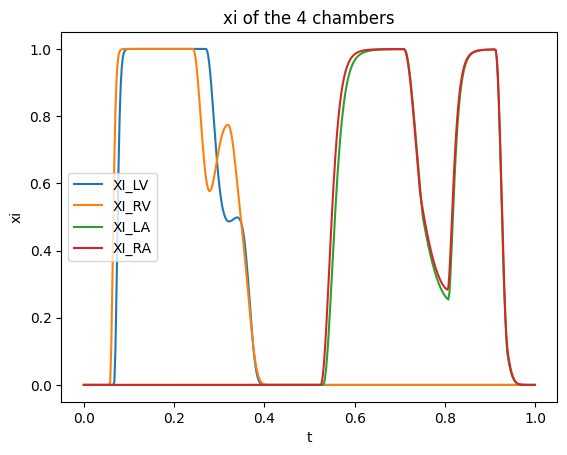

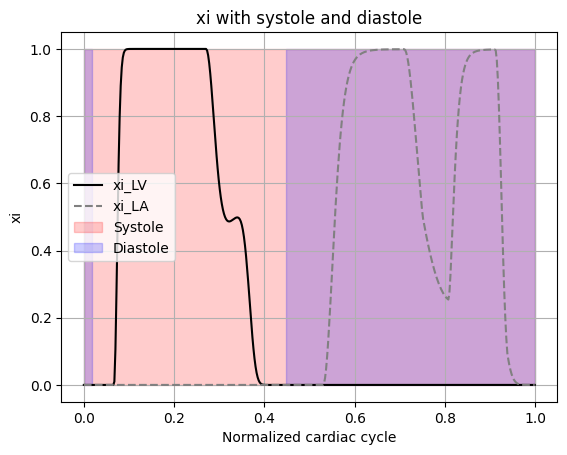

In [101]:
for comp, var in m.getAllNames():
    if var == "xi":
        print(comp)

#PLOT XI_LV, XI_RV, XI_LA, XI_RA in fucntion of time for the last cycle
plt.figure()
plt.plot(data["t_norm"], m.getVariable("LV","xi")[idx], label="XI_LV")
plt.plot(data["t_norm"], m.getVariable("RV","xi")[idx], label="XI_RV")
plt.plot(data["t_norm"], m.getVariable("LA","xi")[idx], label="XI_LA")
plt.plot(data["t_norm"], m.getVariable("RA","xi")[idx], label="XI_RA")
plt.xlabel("t")
plt.ylabel("xi")
plt.title("xi of the 4 chambers")
plt.legend()
plt.show()


dt = data["t"][1] - data["t"][0]
dVdt = np.gradient(data["V_LV"], dt)

systole = data["Q_AA"] > 0
diastole = dVdt > 0

t = data["t_norm"]
xi_LV = m.getVariable("LV", "xi")[idx]
xi_LA = m.getVariable("LA", "xi")[idx]

plt.figure()
plt.plot(t, xi_LV, label="xi_LV", color='black')
plt.plot(t, xi_LA, label="xi_LA", color='gray', linestyle='--')
plt.fill_between(t, 0, 1, where=systole, color='red', alpha=0.2, label='Systole')
plt.fill_between(t, 0, 1, where=diastole, color='blue', alpha=0.2, label='Diastole')
plt.xlabel("Normalized cardiac cycle")
plt.ylabel("xi")
plt.title("xi with systole and diastole")
plt.legend()
plt.grid()
plt.show()

In [102]:
# We can also check that all the parameters we wanted to scale are actually scaled
print(m.getAllNames())



[('LA', 'C'), ('LA', 'Lsc'), ('LA', 'Vcav'), ('LA', 'Qo'), ('LA', 'xi'), ('RA', 'C'), ('RA', 'Lsc'), ('RA', 'Vcav'), ('RA', 'Qo'), ('RA', 'xi'), ('RV', 'C'), ('RV', 'Lsc'), ('RV', 'Vcav'), ('RV', 'Qo'), ('PA_RCL', 'Pi'), ('RV', 'xi'), ('LV', 'C'), ('LV', 'Lsc'), ('LV', 'Vcav'), ('LV', 'Qo'), ('LV', 'xi'), ('AA_RCL', 'Qo'), ('AA_RCL', 'Pi'), ('AA_RCL', 'V'), ('AAA_RCL', 'Qo'), ('AAA_RCL', 'Pi'), ('AAA_RCL', 'V'), ('DAA_RCL', 'Qo'), ('DAA_RCL', 'Pi'), ('DAA_RCL', 'V'), ('PA_RCL', 'Qo'), ('PA_RCL', 'V'), ('LUNG_RCL', 'Qo'), ('LUNG_RCL', 'Pi'), ('LUNG_RCL', 'V'), ('SVC_RCL', 'Qo'), ('SVC_RCL', 'Pi'), ('SVC_RCL', 'V'), ('AO2_RCL', 'Qo'), ('AO2_RCL', 'Pi'), ('AO2_RCL', 'V'), ('UV_RCL', 'Qo'), ('UV_RCL', 'Pi'), ('UV_RCL', 'V'), ('IVC_RCL', 'Qo'), ('IVC_RCL', 'Pi'), ('IVC_RCL', 'V'), ('BrachT_RCL', 'Qo'), ('Bif_AAin_AAA1out_BrachT2out', 'Qo2'), ('BrachT_RCL', 'Pi'), ('BrachT_RCL', 'V'), ('SubAR_RCL', 'Qo'), ('SubAR_RCL', 'Pi'), ('SubAR_RCL', 'V'), ('ICaroAR_RCL', 'Qo'), ('ICaroAR_RCL', 'Pi'), 